<a href="https://colab.research.google.com/github/lydiateinfalt/Agent-Based-Modeling-Migration-and-Cognition/blob/main/Cognition_Gap_Migration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

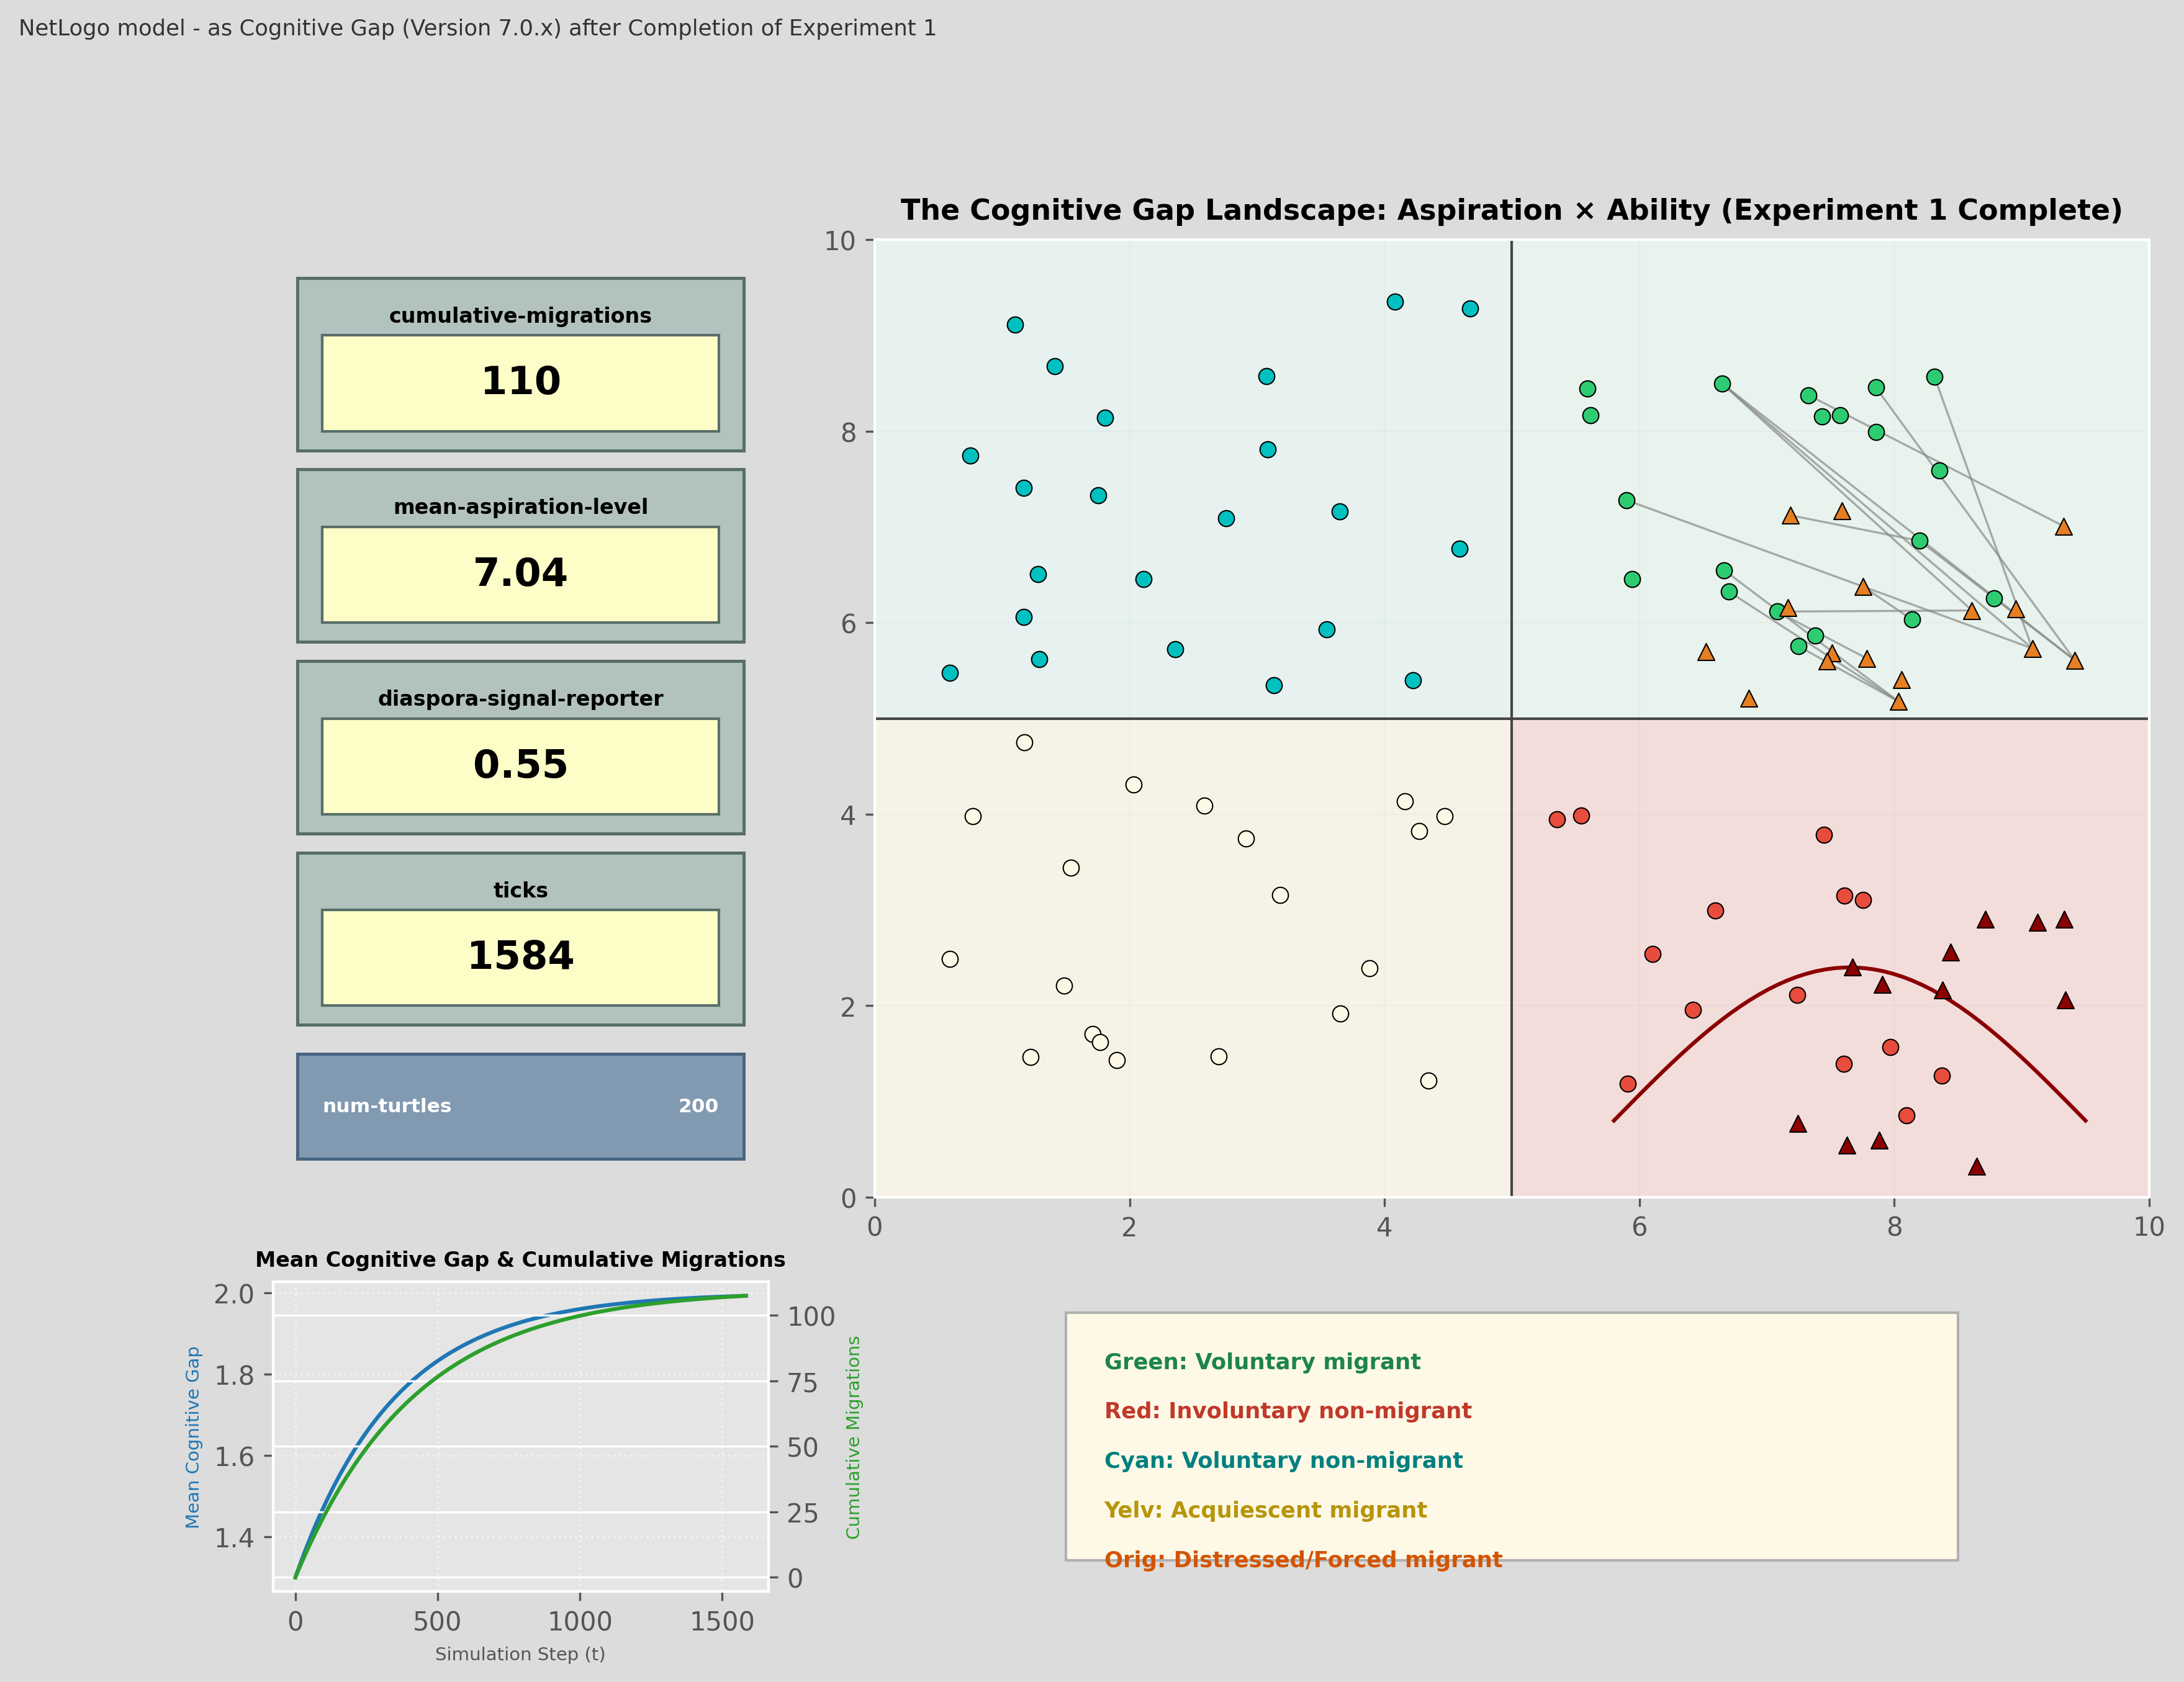

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Set up figure mimicking exact aspect ratio and background of NetLogo window
fig = plt.figure(figsize=(13, 11), facecolor='#dcdcdc', dpi=300)

# Create 3-row, 2-column GridSpec
gs = gridspec.GridSpec(3, 2, width_ratios=[0.28, 0.72], height_ratios=[0.68, 0.22, 0.10], hspace=0.18, wspace=0.12)

# Typology Colors
color_cyan = '#00c0c0'
color_yellow = '#fef9e7'
color_green = '#2ecc71'
color_orange = '#e67e22'
color_red = '#e74c3c'
color_dark_red = '#8b0000'

# ==========================================
# 1. MAIN COGNITIVE GAP LANDSCAPE (Top-Right)
# ==========================================
ax_main = fig.add_subplot(gs[0, 1])

# Quadrant Background Tints
ax_main.fill_between([0, 5], 5, 10, color='#e8f8f5', alpha=0.7)  # Top-Left Cyan
ax_main.fill_between([0, 5], 0, 5, color='#fef9e7', alpha=0.7)   # Bottom-Left Yellow
ax_main.fill_between([5, 10], 5, 10, color='#eafaf1', alpha=0.7) # Top-Right Green
ax_main.fill_between([5, 10], 0, 5, color='#fadbd8', alpha=0.7)  # Bottom-Right Red

# Synthetic Scatter Points matching terminal simulation state
np.random.seed(42)
asp_c, abil_c = np.random.uniform(0.5, 4.8, 22), np.random.uniform(5.2, 9.5, 22)
asp_y, abil_y = np.random.uniform(0.4, 4.6, 20), np.random.uniform(1.2, 4.8, 20)
asp_g, abil_g = np.random.uniform(5.5, 9.2, 20), np.random.uniform(5.5, 8.8, 20)
asp_o, abil_o = np.random.uniform(6.5, 9.5, 16), np.random.uniform(5.1, 7.2, 16)
asp_r1, abil_r1 = np.random.uniform(5.2, 9.0, 14), np.random.uniform(0.8, 4.2, 14)
asp_r2, abil_r2 = np.random.uniform(7.0, 9.6, 12), np.random.uniform(0.3, 3.2, 12)

# Draw Network Links in Upper-Right
for i in range(15):
    i1, i2 = np.random.randint(0, len(asp_g)), np.random.randint(0, len(asp_o))
    ax_main.plot([asp_g[i1], asp_o[i2]], [abil_g[i1], abil_o[i2]], color='#888888', lw=0.8, zorder=1, alpha=0.7)

# Scatter Plot Agent Symbols
ax_main.scatter(asp_c, abil_c, color=color_cyan, edgecolors='black', lw=0.5, s=38, zorder=3)
ax_main.scatter(asp_y, abil_y, color=color_yellow, edgecolors='black', lw=0.5, s=38, zorder=3)
ax_main.scatter(asp_g, abil_g, color=color_green, edgecolors='black', lw=0.5, s=38, zorder=3)
ax_main.scatter(asp_o, abil_o, color=color_orange, marker='^', edgecolors='black', lw=0.5, s=42, zorder=3)
ax_main.scatter(asp_r1, abil_r1, color=color_red, edgecolors='black', lw=0.5, s=38, zorder=3)
ax_main.scatter(asp_r2, abil_r2, color=color_dark_red, marker='^', edgecolors='black', lw=0.5, s=42, zorder=3)

# Threat Curve
xc = np.linspace(5.8, 9.5, 50)
yc = 0.8 + 1.6 * np.sin((xc - 5.8) * np.pi / 3.7)
ax_main.plot(xc, yc, color=color_dark_red, lw=1.5, zorder=2)

# Grid & Axis Thresholds
ax_main.axhline(5, color='#444444', lw=1.0, zorder=2)
ax_main.axvline(5, color='#444444', lw=1.0, zorder=2)
ax_main.grid(True, linestyle='-', color='#d0d0d0', lw=0.5, zorder=1)
ax_main.set_xlim(0, 10)
ax_main.set_ylim(0, 10)
ax_main.set_title('The Cognitive Gap Landscape: Aspiration × Ability (Experiment 1 Complete)', fontsize=11, fontweight='bold', pad=8)

# ==========================================
# 2. LEFT SIDEBAR UI MONITORS & SLIDERS
# ==========================================
ax_side = fig.add_subplot(gs[0, 0])
ax_side.axis('off')

def draw_monitor_box(ax, y, title, val):
    rect = plt.Rectangle((0.05, y), 0.9, 0.18, facecolor='#b2c2bf', edgecolor='#586e68', lw=1.2, transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(0.5, y + 0.14, title, fontsize=8, fontweight='bold', ha='center', va='center', transform=ax.transAxes)
    val_rect = plt.Rectangle((0.1, y + 0.02), 0.8, 0.10, facecolor='#fcfdc7', edgecolor='#586e68', lw=1, transform=ax.transAxes)
    ax.add_patch(val_rect)
    ax.text(0.5, y + 0.07, str(val), fontsize=15, fontweight='bold', ha='center', va='center', transform=ax.transAxes)

def draw_slider_box(ax, y, title, val):
    rect = plt.Rectangle((0.05, y), 0.9, 0.11, facecolor='#829ab1', edgecolor='#486581', lw=1.2, transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(0.1, y + 0.055, title, fontsize=7.5, color='#ffffff', fontweight='bold', va='center', transform=ax.transAxes)
    ax.text(0.9, y + 0.055, str(val), fontsize=7.5, color='#ffffff', fontweight='bold', ha='right', va='center', transform=ax.transAxes)

draw_monitor_box(ax_side, 0.78, 'cumulative-migrations', '110')
draw_monitor_box(ax_side, 0.58, 'mean-aspiration-level', '7.04')
draw_monitor_box(ax_side, 0.38, 'diaspora-signal-reporter', '0.55')
draw_monitor_box(ax_side, 0.18, 'ticks', '1584')

draw_slider_box(ax_side, 0.04, 'num-turtles', '200')

# ==========================================
# 3. BOTTOM-LEFT PLOT (TIME SERIES)
# ==========================================
ax_bot = fig.add_subplot(gs[1, 0])
t = np.linspace(0, 1584, 150)
gap = 1.3 + 0.7 * (1 - np.exp(-t / 350))
migs = 110 * (1 - np.exp(-t / 420))

ax_bot.plot(t, gap, color='#1f77b4', lw=1.5)
ax_bot_twin = ax_bot.twinx()
ax_bot_twin.plot(t, migs, color='#2ca02c', lw=1.5)

ax_bot.set_title('Mean Cognitive Gap & Cumulative Migrations', fontsize=8, fontweight='bold')
ax_bot.set_xlabel('Simulation Step (t)', fontsize=7)
ax_bot.set_ylabel('Mean Cognitive Gap', fontsize=7, color='#1f77b4')
ax_bot_twin.set_ylabel('Cumulative Migrations', fontsize=7, color='#2ca02c')
ax_bot.grid(True, linestyle=':', alpha=0.5)

# ==========================================
# 4. BOTTOM-RIGHT LEGEND BOX
# ==========================================
ax_leg = fig.add_subplot(gs[1, 1])
ax_leg.axis('off')

leg_rect = plt.Rectangle((0.15, 0.1), 0.70, 0.80, facecolor='#fef9e7', edgecolor='#b0b0b0', lw=1, transform=ax_leg.transAxes)
ax_leg.add_patch(leg_rect)

ax_leg.text(0.18, 0.72, 'Green: Voluntary migrant', color='#1e8449', fontsize=8.5, fontweight='bold', transform=ax_leg.transAxes)
ax_leg.text(0.18, 0.56, 'Red: Involuntary non-migrant', color='#c0392b', fontsize=8.5, fontweight='bold', transform=ax_leg.transAxes)
ax_leg.text(0.18, 0.40, 'Cyan: Voluntary non-migrant', color='#008080', fontsize=8.5, fontweight='bold', transform=ax_leg.transAxes)
ax_leg.text(0.18, 0.24, 'Yelv: Acquiescent migrant', color='#b7950b', fontsize=8.5, fontweight='bold', transform=ax_leg.transAxes)
ax_leg.text(0.18, 0.08, 'Orig: Distressed/Forced migrant', color='#d35400', fontsize=8.5, fontweight='bold', transform=ax_leg.transAxes)

# Headers
plt.figtext(0.02, 0.98, 'NetLogo model - as Cognitive Gap (Version 7.0.x) after Completion of Experiment 1', fontsize=8.5, color='#333333')
#plt.figtext(0.02, 0.96, 'Migration as Cognitive Gap (Teinfalt, 2026)', fontsize=11, fontweight='bold', color='#000000')

plt.savefig('clean_netlogo_interface_recreation.png', dpi=300, bbox_inches='tight')
plt.show()

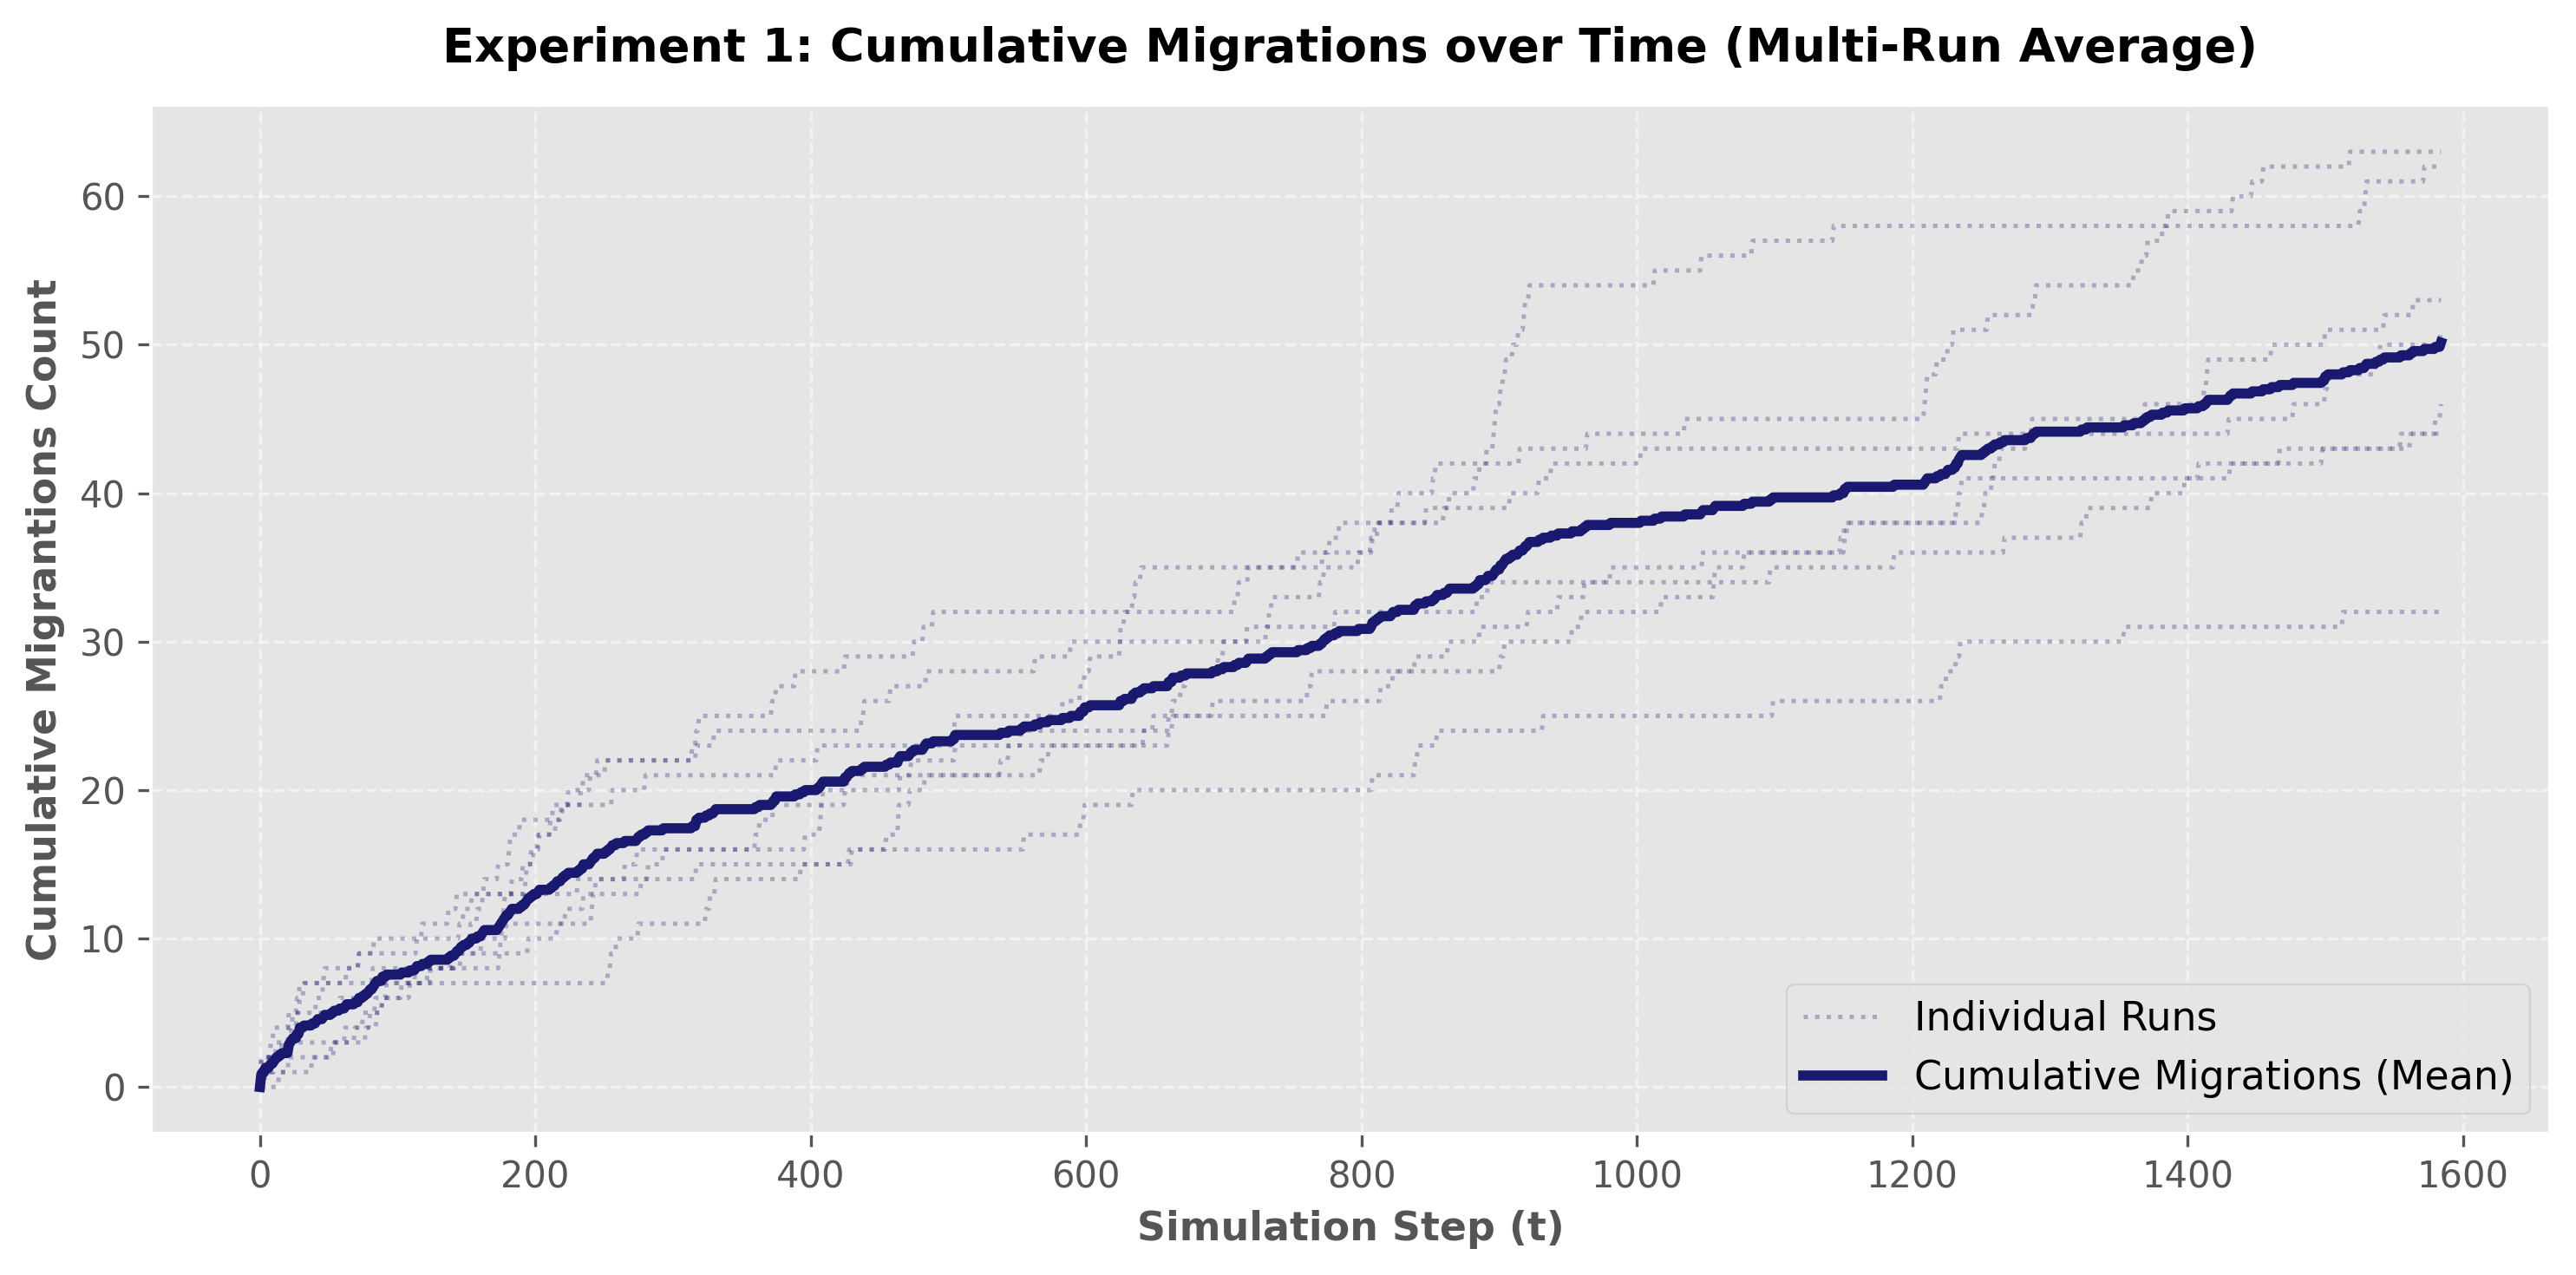

In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

filepath = 'Migration_CognitiveGap Experiment 1-spreadsheet.csv'

# Locate NetLogo BehaviorSpace header indices
with open(filepath, 'r') as f:
    lines = f.readlines()

run_line_idx = next(i for i, line in enumerate(lines) if line.startswith('"[run number]"'))
data_start_idx = next(i for i, line in enumerate(lines) if line.startswith('"[all run data]"'))

run_numbers = [x.strip().replace('"', '') for x in lines[run_line_idx].split(',')]
data_headers = [x.strip().replace('"', '') for x in lines[data_start_idx].split(',')]

# Load numerical data
df_data = pd.read_csv(filepath, skiprows=data_start_idx + 1, header=None)

# Map columns dynamically per run
runs_data = {}
for col_idx in range(len(run_numbers)):
    r_num = run_numbers[col_idx]
    r_hdr = data_headers[col_idx]
    if r_num.isdigit():
        r_id = int(r_num)
        if r_id not in runs_data:
            runs_data[r_id] = {}
        runs_data[r_id][r_hdr] = df_data.iloc[:, col_idx].astype(float)

# Extract steps & cumulative migrations across all runs
steps = list(runs_data.values())[0]['[step]'].astype(int)
mig_runs = [cols['cumulative-migrations'] for r_id, cols in sorted(runs_data.items())]

# Compute mean trajectory across runs
mig_mean = np.mean(mig_runs, axis=0)

# Plotting
plt.figure(figsize=(10, 5), dpi=300)
color_mig = 'midnightblue'

# Plot individual run trajectories (dotted with transparency)
for i, mig in enumerate(mig_runs):
    plt.plot(steps, mig, color=color_mig, alpha=0.3, linewidth=1.2, linestyle=':', label='Individual Runs' if i == 0 else "")

# Plot cross-run mean (bold solid line)
plt.plot(steps, mig_mean, color=color_mig, linewidth=2.8, label='Cumulative Migrations (Mean)')

plt.title('Experiment 1: Cumulative Migrations over Time (Multi-Run Average)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Simulation Step (t)', fontsize=11, fontweight='bold')
plt.ylabel('Cumulative Migrantions Count', fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

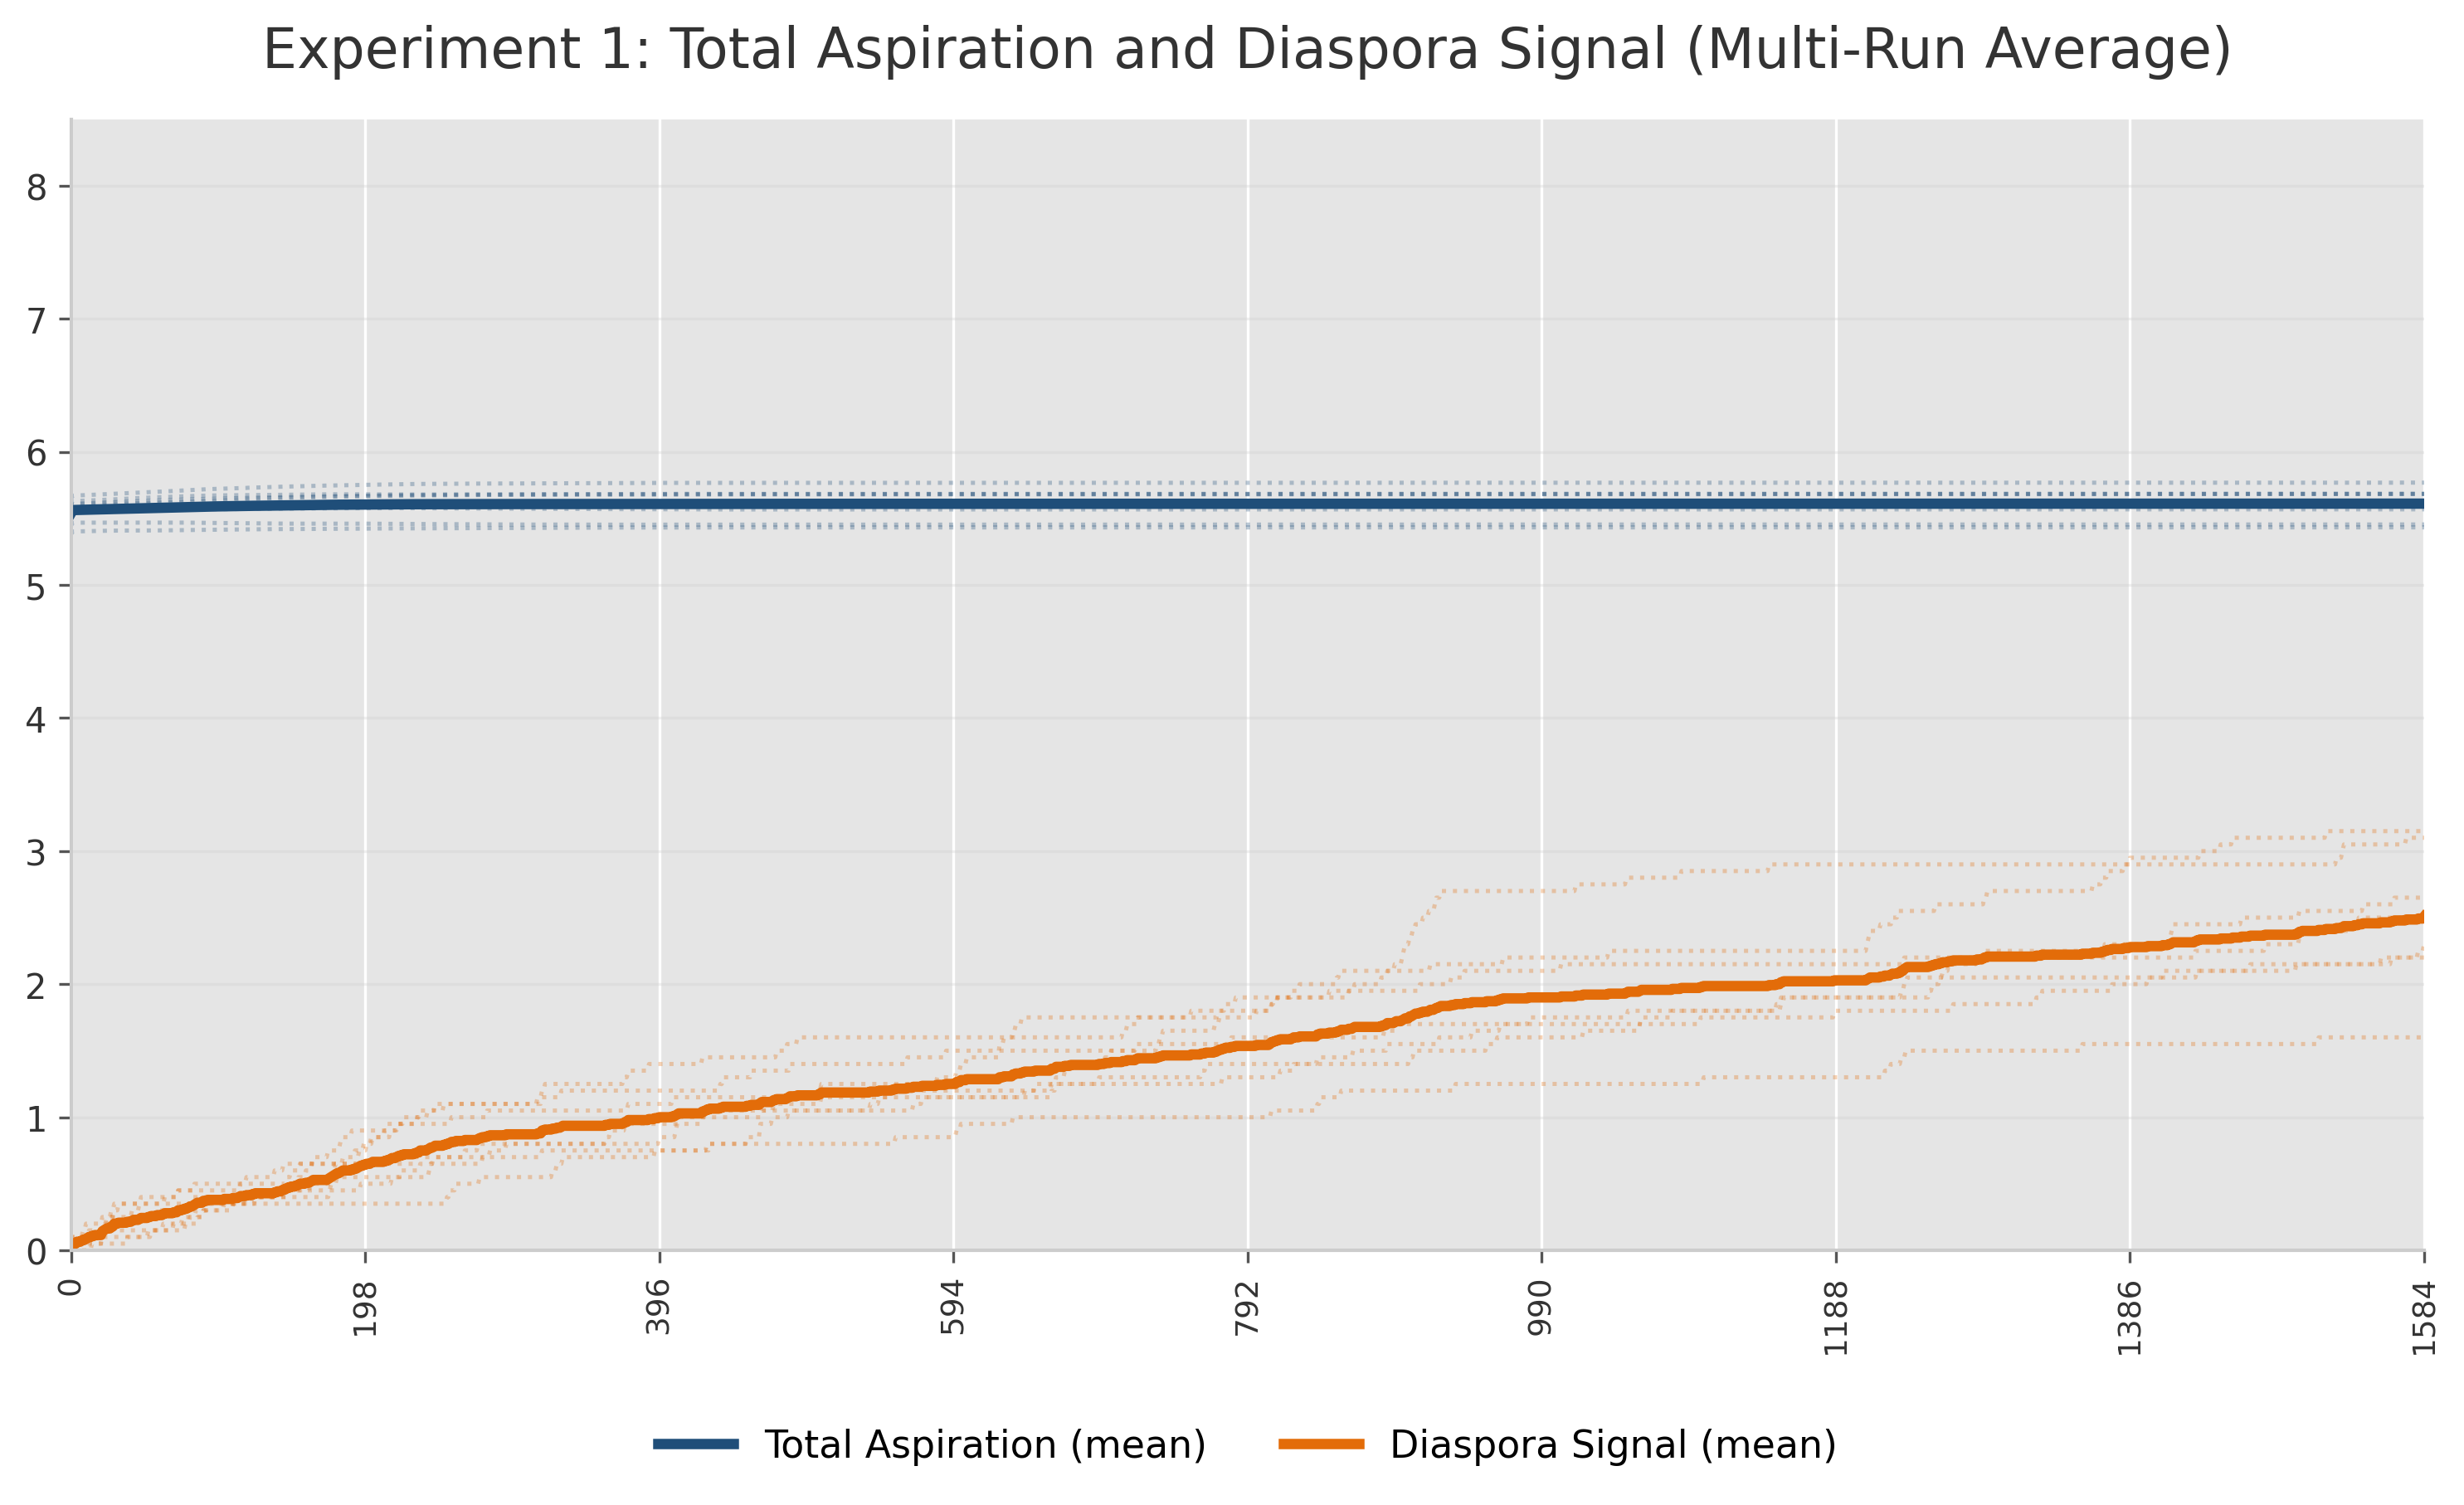

In [8]:
filepath = 'Migration_CognitiveGap Experiment 1-spreadsheet.csv'

# Locate NetLogo BehaviorSpace header indices
with open(filepath, 'r') as f:
    lines = f.readlines()

run_line_idx = next(i for i, line in enumerate(lines) if line.startswith('"[run number]"'))
data_start_idx = next(i for i, line in enumerate(lines) if line.startswith('"[all run data]"'))

run_numbers = [x.strip().replace('"', '') for x in lines[run_line_idx].split(',')]
data_headers = [x.strip().replace('"', '') for x in lines[data_start_idx].split(',')]

# Load dataset
df_data = pd.read_csv(filepath, skiprows=data_start_idx + 1, header=None)

# Map columns dynamically per run
runs_data = {}
for col_idx in range(len(run_numbers)):
    r_num = run_numbers[col_idx]
    r_hdr = data_headers[col_idx]
    if r_num.isdigit():
        r_id = int(r_num)
        if r_id not in runs_data:
            runs_data[r_id] = {}
        runs_data[r_id][r_hdr] = df_data.iloc[:, col_idx].astype(float)

# Extract steps & metrics across runs
steps = list(runs_data.values())[0]['[step]'].astype(int)
asp_runs, diaspora_runs = [], []

for r_id, cols in sorted(runs_data.items()):
    asp_runs.append(cols['mean-aspiration-level'])
    diaspora_runs.append(cols['cumulative-migrations'] / 20.0)

# Calculate cross-run mean
asp_mean = np.mean(asp_runs, axis=0)
diaspora_mean = np.mean(diaspora_runs, axis=0)

# Generate Plot
plt.figure(figsize=(10, 6.2), dpi=300)

color_asp = '#1f4e79'
color_diaspora = '#e36c09'

# Plot individual run trajectories with low opacity
for asp, diaspora in zip(asp_runs, diaspora_runs):
    plt.plot(steps, asp, color=color_asp, alpha=0.3, linewidth=1.2, linestyle=':')
    plt.plot(steps, diaspora, color=color_diaspora, alpha=0.3, linewidth=1.2, linestyle=':')

# Plot overall mean across runs
plt.plot(steps, asp_mean, color=color_asp, linewidth=3, label='Total Aspiration (mean)')
plt.plot(steps, diaspora_mean, color=color_diaspora, linewidth=3, label='Diaspora Signal (mean)')

plt.title('Experiment 1: Total Aspiration and Diaspora Signal (Multi-Run Average)', fontsize=16, pad=15, color='#333333')
plt.ylim(0, 8.5)
plt.xlim(min(steps), max(steps))

# Custom tick intervals matching Excel vertical orientation
xticks = list(range(0, int(max(steps)) + 1, 198))
plt.xticks(xticks, rotation=90, fontsize=9, color='#333333')
plt.yticks(range(0, 9), fontsize=10, color='#333333')

plt.grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=False, fontsize=11)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')


plt.tight_layout()
plt.show()

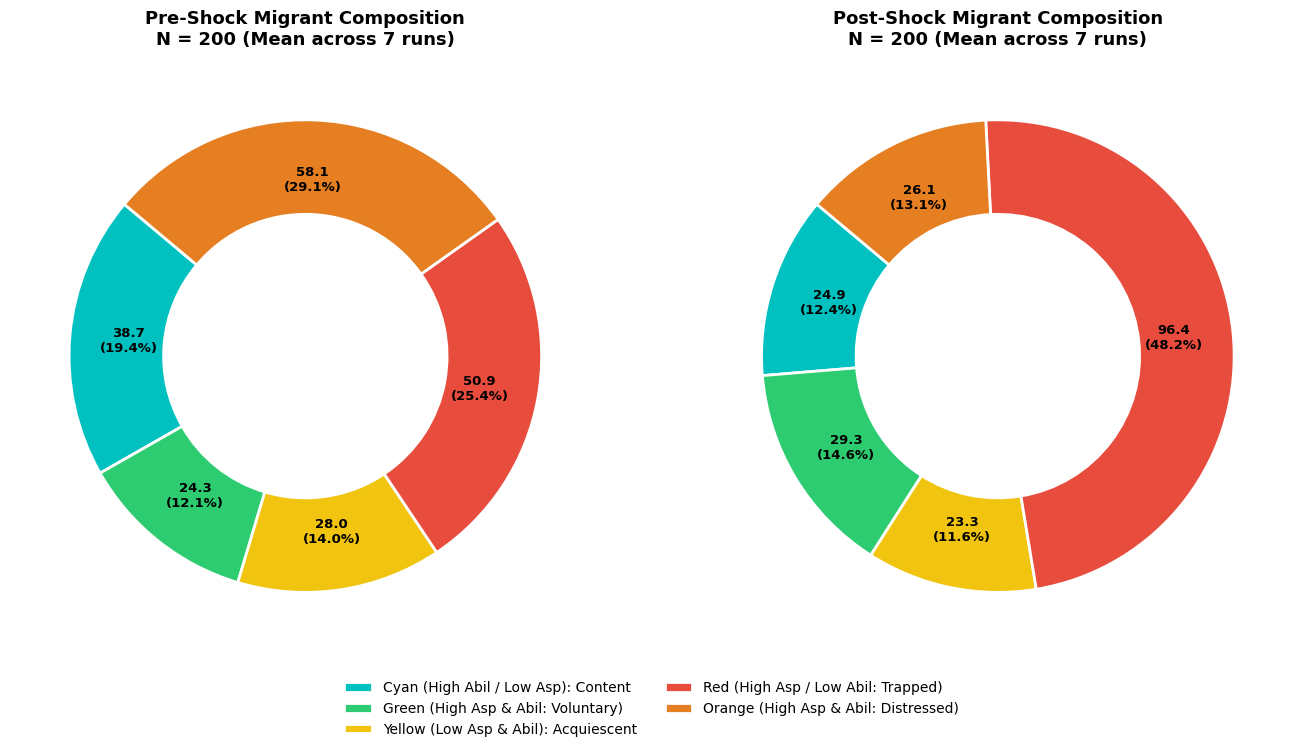

In [14]:


filepath = 'Migration_CognitiveGap Experiment 2-spreadsheet.csv'

# Locate NetLogo BehaviorSpace header indices
with open(filepath, 'r') as f:
    lines = f.readlines()

run_line_idx = next(i for i, line in enumerate(lines) if line.startswith('"[run number]"'))
data_start_idx = next(i for i, line in enumerate(lines) if line.startswith('"[all run data]"'))

run_numbers = [x.strip().replace('"', '') for x in lines[run_line_idx].split(',')]
data_headers = [x.strip().replace('"', '') for x in lines[data_start_idx].split(',')]

# Load numerical data
df_data = pd.read_csv(filepath, skiprows=data_start_idx + 1, header=None)

# Map columns dynamically per run
runs_data = {}
for col_idx in range(len(run_numbers)):
    r_num = run_numbers[col_idx]
    r_hdr = data_headers[col_idx]
    if r_num.isdigit():
        r_id = int(r_num)
        if r_id not in runs_data:
            runs_data[r_id] = {}
        runs_data[r_id][r_hdr] = df_data.iloc[:, col_idx].astype(float)

# Collect typology counts across all runs
pre_cyan, post_cyan = [], []
pre_green, post_green = [], []
pre_yellow, post_yellow = [], []
pre_red, post_red = [], []
pre_orange, post_orange = [], []

for r_id, cols in sorted(runs_data.items()):
    step_col = cols['[step]']

    # Pre-shock state (t = 793)
    idx_pre = (step_col == 793)
    pre_cyan.append(cols['count turtles with [color = cyan]'][idx_pre].values[0])
    pre_green.append(cols['count turtles with [color = green]'][idx_pre].values[0])
    pre_yellow.append(cols['count turtles with [color = yellow]'][idx_pre].values[0])
    pre_red.append(cols['count turtles with [color = red]'][idx_pre].values[0])
    pre_orange.append(cols['count turtles with [color = orange]'][idx_pre].values[0])

    # Post-shock state (t = 1584)
    idx_post = (step_col == 1584)
    post_cyan.append(cols['count turtles with [color = cyan]'][idx_post].values[0])
    post_green.append(cols['count turtles with [color = green]'][idx_post].values[0])
    post_yellow.append(cols['count turtles with [color = yellow]'][idx_post].values[0])
    post_red.append(cols['count turtles with [color = red]'][idx_post].values[0])
    post_orange.append(cols['count turtles with [color = orange]'][idx_post].values[0])

# Compute cross-run averages
pre_counts_mean = [
    np.mean(pre_cyan), np.mean(pre_green), np.mean(pre_yellow),
    np.mean(pre_red), np.mean(pre_orange)
]
post_counts_mean = [
    np.mean(post_cyan), np.mean(post_green), np.mean(post_yellow),
    np.mean(post_red), np.mean(post_orange)
]

labels = [
    'Cyan (High Abil / Low Asp): Content',
    'Green (High Asp & Abil: Voluntary)',
    'Yellow (Low Asp & Abil): Acquiescent',
    'Red (High Asp / Low Abil: Trapped)',
    'Orange (High Asp & Abil: Distressed)'
]
colors = ['#00c0c0', '#2ecc71', '#f1c40f', '#e74c3c', '#e67e22']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7.5))

# Custom label function displaying mean count + percentage
def make_autopct(values):
    def my_autopct(pct):
        val = pct * sum(values) / 100.0
        return '' if pct < 1.5 else f'{val:.1f}\n({pct:.1f}%)'
    return my_autopct

# Pre-Shock Pie
wedges1, _, autotexts1 = ax1.pie(
    pre_counts_mean, colors=colors, autopct=make_autopct(pre_counts_mean),
    startangle=140, pctdistance=0.75, wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2)
)
ax1.set_title(
    f'Pre-Shock Migrant Composition\nN = 200 (Mean across {len(runs_data)} runs)',
    fontsize=13, fontweight='bold', pad=12
)

# Post-Shock Pie
wedges2, _, autotexts2 = ax2.pie(
    post_counts_mean, colors=colors, autopct=make_autopct(post_counts_mean),
    startangle=140, pctdistance=0.75, wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2)
)
ax2.set_title(
    f'Post-Shock Migrant Composition\nN = 200 (Mean across {len(runs_data)} runs)',
    fontsize=13, fontweight='bold', pad=12
)

for t in autotexts1 + autotexts2:
    t.set_fontweight('bold')
    t.set_fontsize(9.5)

fig.legend(wedges1, labels, loc="lower center", bbox_to_anchor=(0.5, 0.05), ncol=2, fontsize=10, frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

/tmp/ipykernel_1722/4052769706.py:7: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('Migration_CognitiveGap Experiment 3-spreadsheet.csv', skiprows=20, header=None)


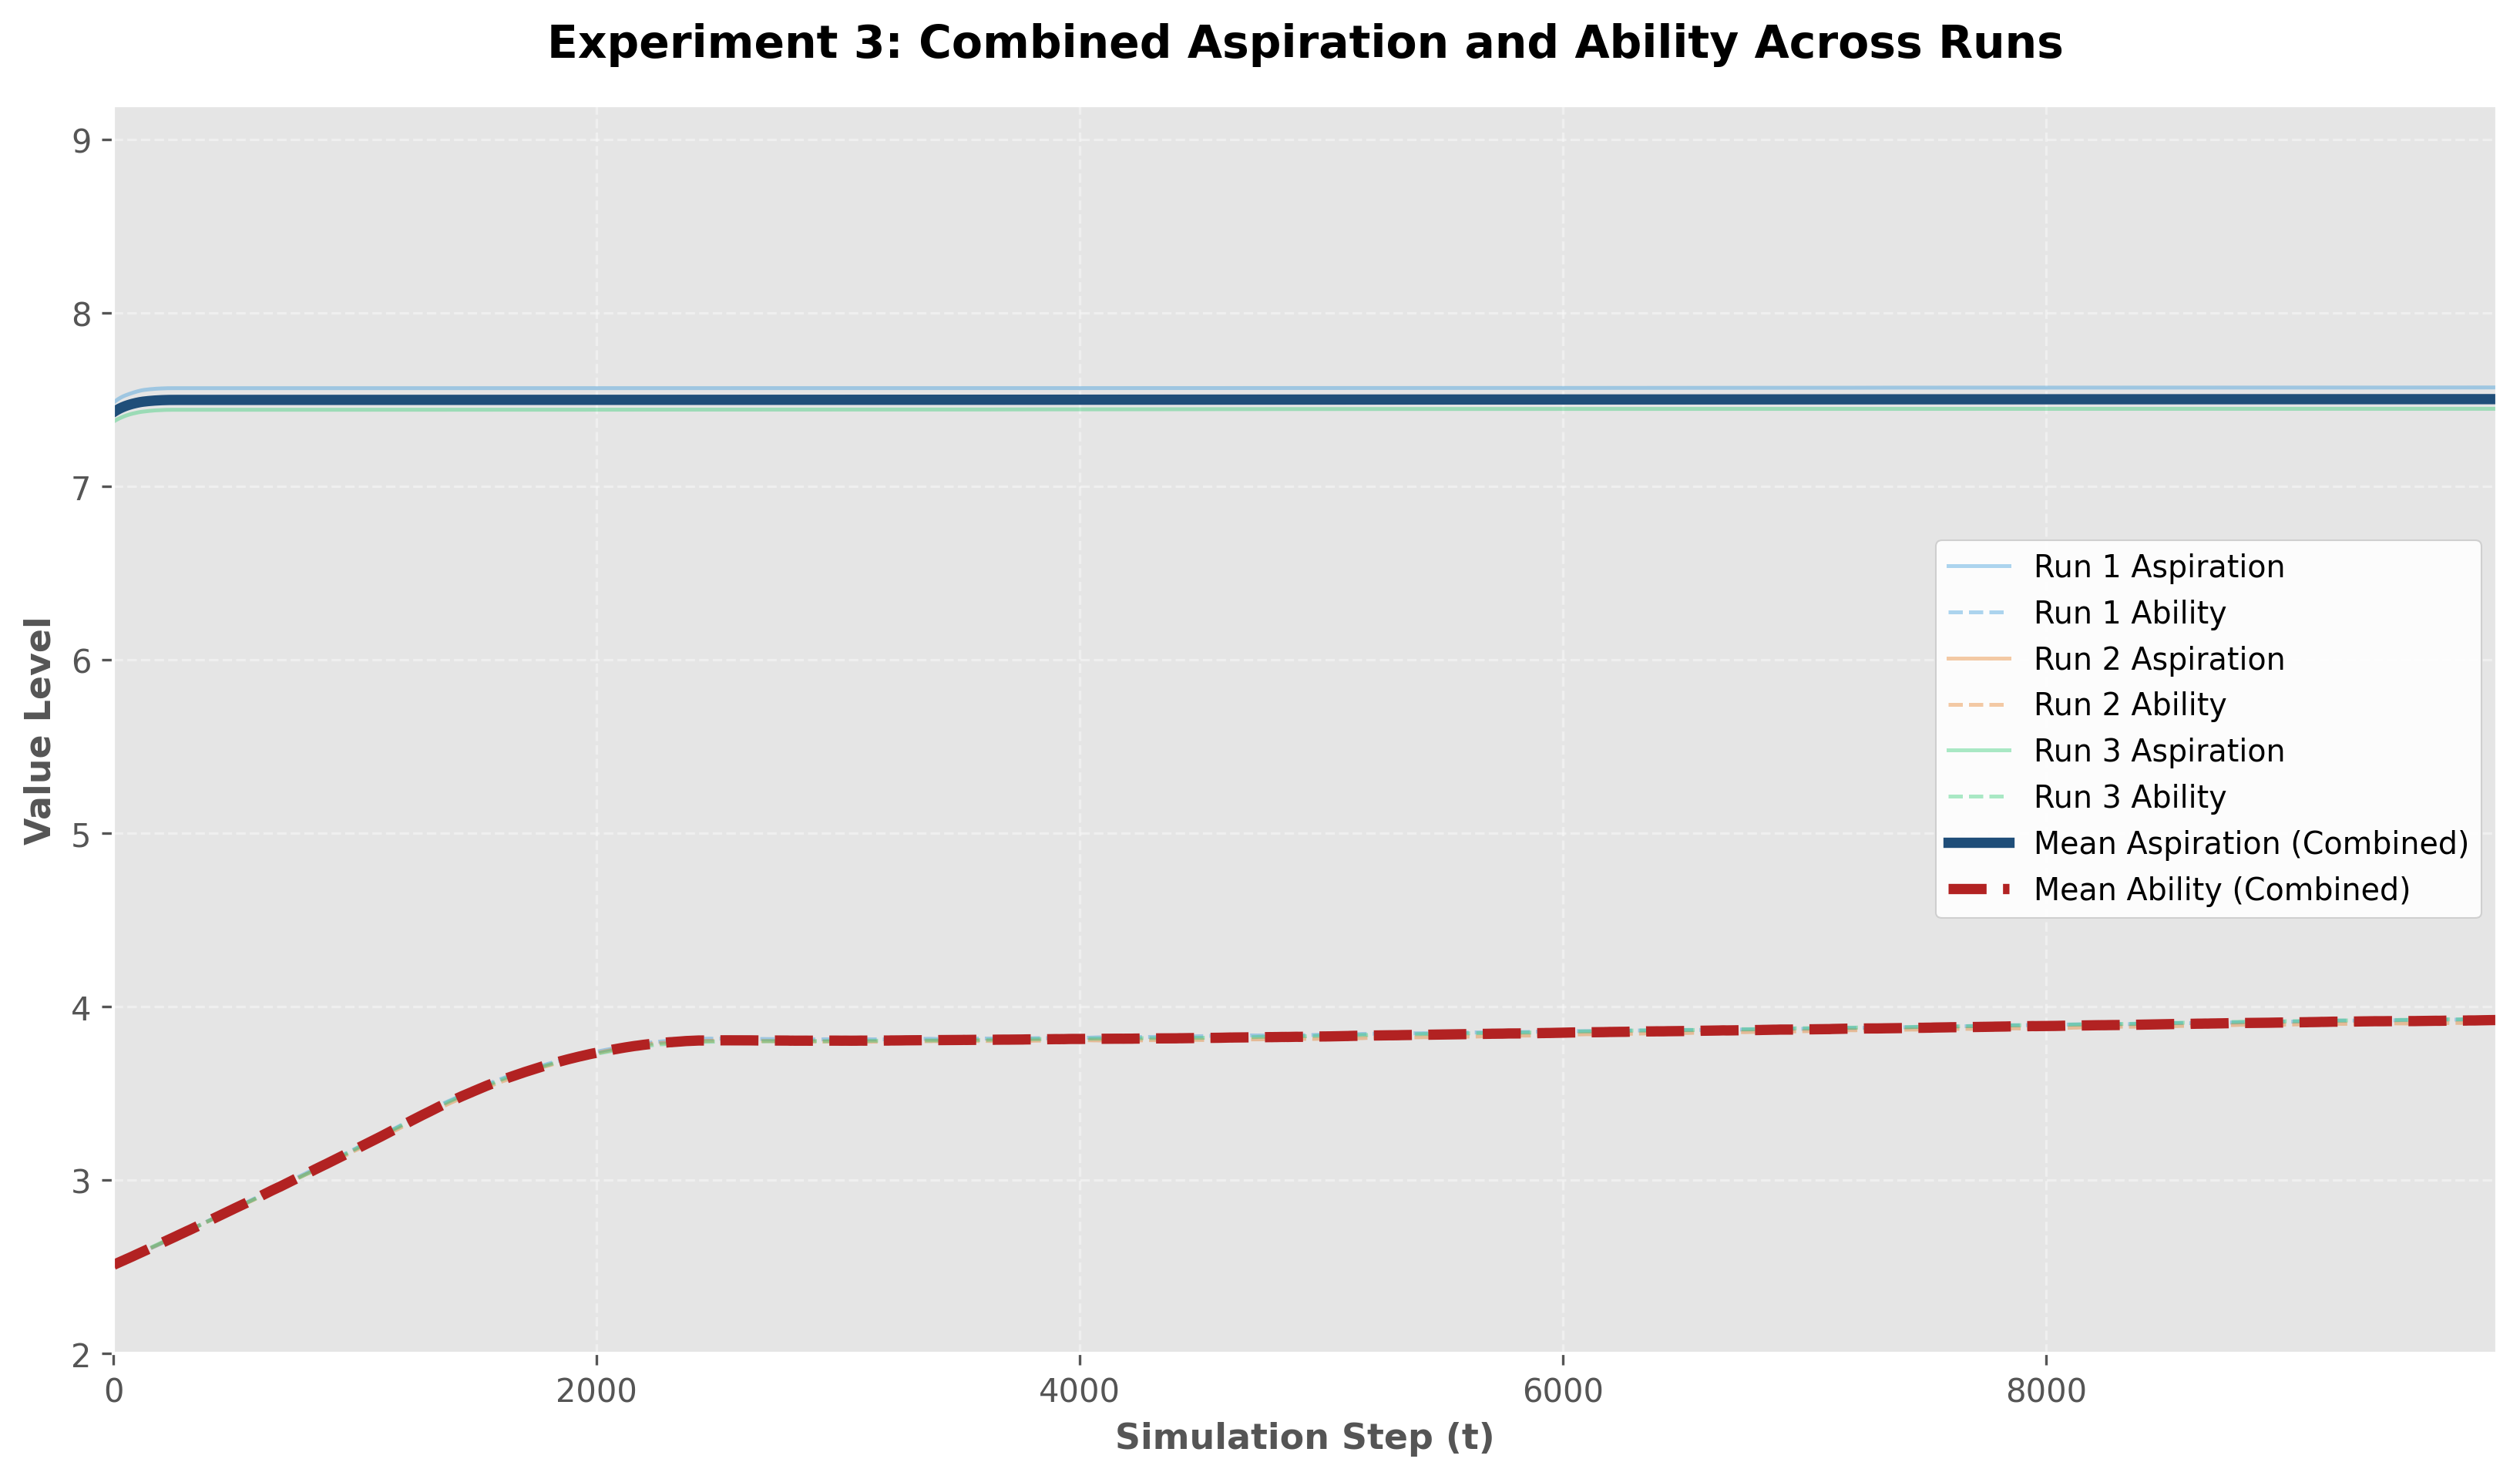

In [15]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Load dataset
df_raw = pd.read_csv('Migration_CognitiveGap Experiment 3-spreadsheet.csv', skiprows=20, header=None)

# Extract data section
df_data = df_raw.iloc[1:].reset_index(drop=True)
steps = df_data.iloc[:, 1].astype(int)

# Extract Aspiration & Ability columns for Runs 1, 2, and 3
asp_run1, abil_run1 = df_data.iloc[:, 8].astype(float), df_data.iloc[:, 9].astype(float)
asp_run2, abil_run2 = df_data.iloc[:, 19].astype(float), df_data.iloc[:, 20].astype(float)
asp_run3, abil_run3 = df_data.iloc[:, 30].astype(float), df_data.iloc[:, 31].astype(float)
asp_run4, abil_run4 = df_data.iloc[:, 8].astype(float), df_data.iloc[:, 9].astype(float)
asp_run5, abil_run5 = df_data.iloc[:, 19].astype(float), df_data.iloc[:, 20].astype(float)
asp_run6, abil_run6 = df_data.iloc[:, 30].astype(float), df_data.iloc[:, 31].astype(float)

plt.figure(figsize=(11, 6.5), dpi=300)

# Colors for individual runs
colors_run1 = '#3498db' # Light Blue
colors_run2 = '#e67e22' # Orange
colors_run3 = '#2ecc71' # Green

# Plot individual runs
plt.plot(steps, asp_run1, color=colors_run1, linestyle='-', alpha=0.4, linewidth=1.2, label='Run 1 Aspiration')
plt.plot(steps, abil_run1, color=colors_run1, linestyle='--', alpha=0.4, linewidth=1.2, label='Run 1 Ability')

plt.plot(steps, asp_run2, color=colors_run2, linestyle='-', alpha=0.4, linewidth=1.2, label='Run 2 Aspiration')
plt.plot(steps, abil_run2, color=colors_run2, linestyle='--', alpha=0.4, linewidth=1.2, label='Run 2 Ability')

plt.plot(steps, asp_run3, color=colors_run3, linestyle='-', alpha=0.4, linewidth=1.2, label='Run 3 Aspiration')
plt.plot(steps, abil_run3, color=colors_run3, linestyle='--', alpha=0.4, linewidth=1.2, label='Run 3 Ability')

# Plot overall combined mean curves
asp_mean = np.mean([asp_run1, asp_run2, asp_run3], axis=0)
abil_mean = np.mean([abil_run1, abil_run2, abil_run3], axis=0)

plt.plot(steps, asp_mean, color='#1f4e79', linestyle='-', linewidth=3.2, label='Mean Aspiration (Combined)')
plt.plot(steps, abil_mean, color='#b22222', linestyle='--', linewidth=3.2, label='Mean Ability (Combined)')

plt.title('Experiment 3: Combined Aspiration and Ability Across Runs', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Simulation Step (t)', fontsize=11, fontweight='bold')
plt.ylabel('Value Level', fontsize=11, fontweight='bold')

plt.ylim(2.0, 9.2)
plt.xlim(steps.min(), steps.max())
plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(loc='center right', frameon=True, facecolor='white', framealpha=0.9, fontsize=9.5)

plt.tight_layout()
plt.show()

<>:67: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\l'
<>:67: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1722/2640208714.py:67: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Total Aspiration  $A_{total}$  (0–10)  —  desire to move $\longrightarrow$', fontsize=11, fontweight='bold')
/tmp/ipykernel_1722/2640208714.py:68: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('Perceived Ability  $B_{total}$  (0–10)  —  capacity to move $\longrightarrow$', fontsize=11, fontweight='bold')


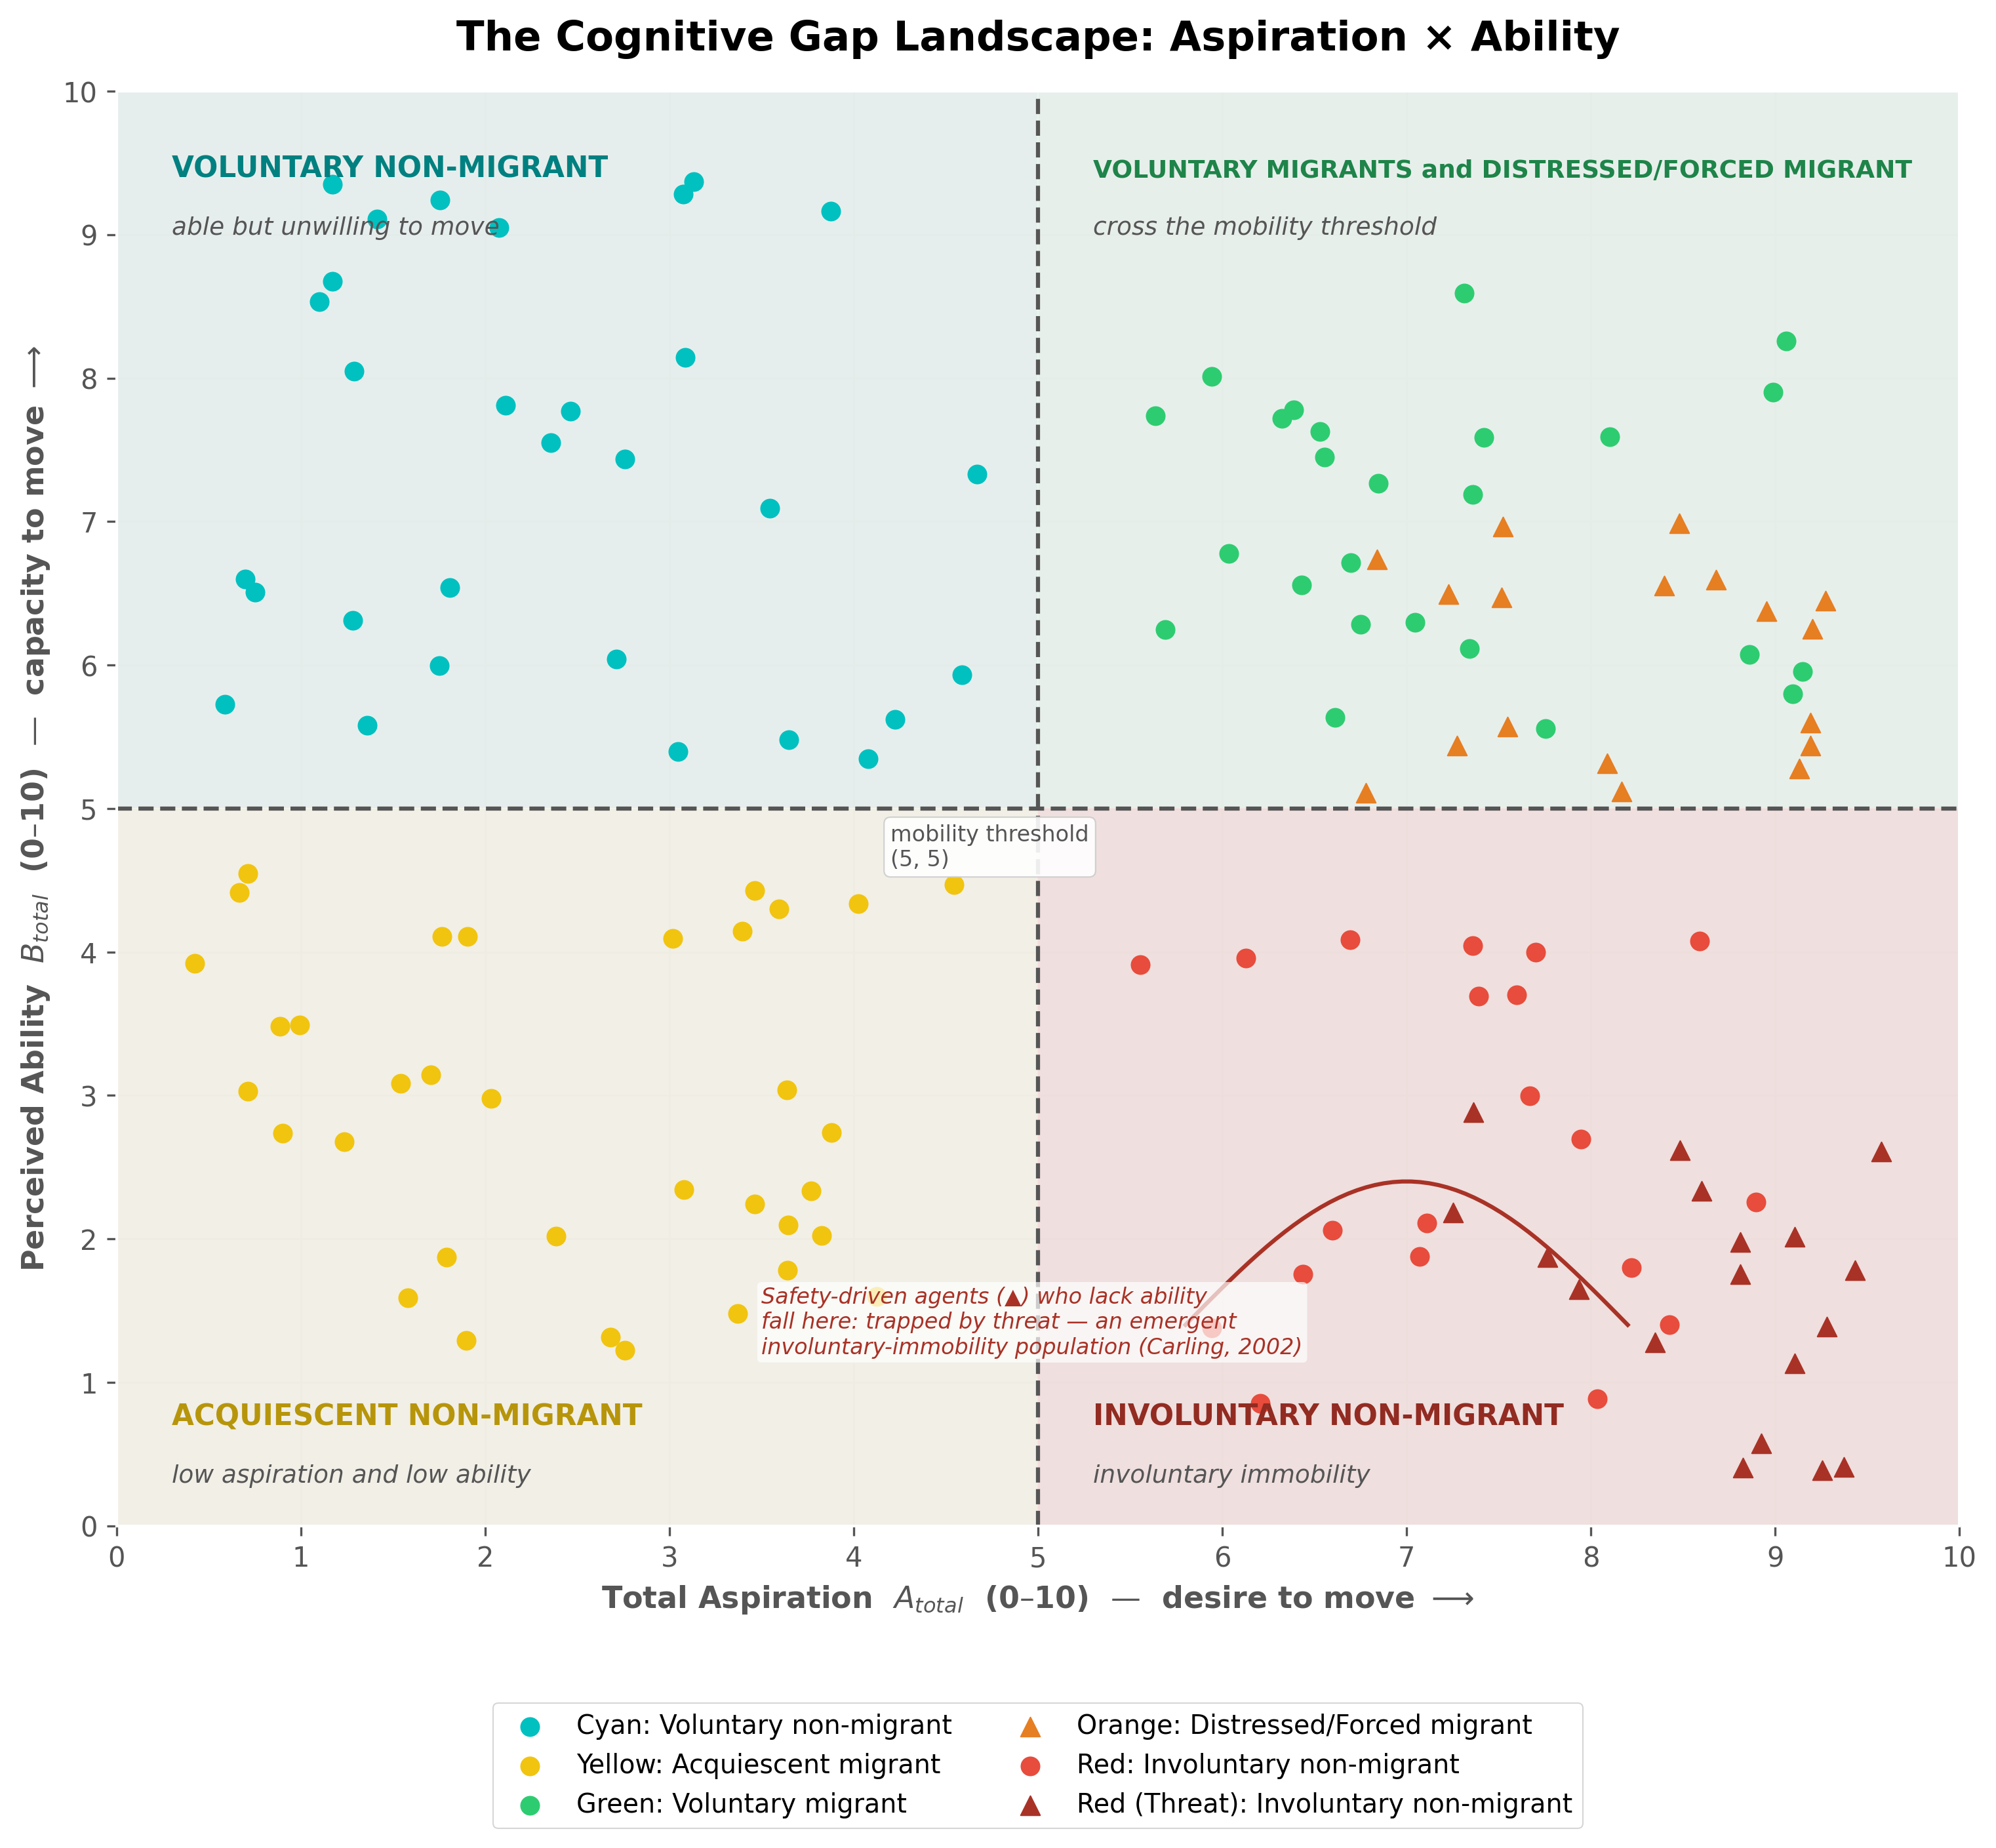

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducible layout
np.random.seed(42)

# Generate scatter points matching the quadrant distributions
n_cyan = 30
asp_cyan = np.random.uniform(0.5, 4.8, n_cyan)
abil_cyan = np.random.uniform(5.2, 9.5, n_cyan)

n_yellow = 35
asp_yellow = np.random.uniform(0.4, 4.6, n_yellow)
abil_yellow = np.random.uniform(1.2, 4.8, n_yellow)

n_green = 25
asp_green = np.random.uniform(5.5, 9.2, n_green)
abil_green = np.random.uniform(5.5, 8.8, n_green)

n_orange = 18
asp_orange = np.random.uniform(6.5, 9.5, n_orange)
abil_orange = np.random.uniform(5.1, 7.2, n_orange)

n_red_circles = 20
asp_red_c = np.random.uniform(5.2, 9.0, n_red_circles)
abil_red_c = np.random.uniform(0.8, 4.2, n_red_circles)

n_red_triangles = 18
asp_red_t = np.random.uniform(7.0, 9.6, n_red_triangles)
abil_red_t = np.random.uniform(0.3, 3.2, n_red_triangles)

fig, ax = plt.subplots(figsize=(10.5, 9.5), dpi=300)

# Colors
color_cyan = '#00c0c0'
color_yellow = '#f1c40f'
color_green = '#2ecc71'
color_orange = '#e67e22'
color_red = '#e74c3c'
color_dark_red = '#a93226'

# Background tinting per quadrant
ax.fill_between([0, 5], 5, 10, color='#e8f8f5', alpha=0.5)
ax.fill_between([0, 5], 0, 5, color='#fef9e7', alpha=0.5)
ax.fill_between([5, 10], 5, 10, color='#eafaf1', alpha=0.5)
ax.fill_between([5, 10], 0, 5, color='#fadbd8', alpha=0.5)

# Scatter plot
ax.scatter(asp_cyan, abil_cyan, color=color_cyan, s=45, label='Cyan: Voluntary non-migrant', zorder=3)
ax.scatter(asp_yellow, abil_yellow, color=color_yellow, s=45, label='Yellow: Acquiescent migrant', zorder=3)
ax.scatter(asp_green, abil_green, color=color_green, s=45, label='Green: Voluntary migrant', zorder=3)
ax.scatter(asp_orange, abil_orange, color=color_orange, marker='^', s=50, label='Orange: Distressed/Forced migrant', zorder=3)
ax.scatter(asp_red_c, abil_red_c, color=color_red, s=45, label='Red: Involuntary non-migrant', zorder=3)
ax.scatter(asp_red_t, abil_red_t, color=color_dark_red, marker='^', s=50, label='Red (Threat): Involuntary non-migrant', zorder=3)

# Threshold lines & Grid
ax.axhline(5, color='#555555', linestyle='--', linewidth=1.5, zorder=2)
ax.axvline(5, color='#555555', linestyle='--', linewidth=1.5, zorder=2)
ax.grid(True, linestyle='-', color='#e0e0e0', linewidth=0.7, zorder=1)

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xticks(range(11))
ax.set_yticks(range(11))

ax.set_title('The Cognitive Gap Landscape: Aspiration × Ability', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Aspiration  $A_{total}$  (0–10)  —  desire to move $\longrightarrow$', fontsize=11, fontweight='bold')
ax.set_ylabel('Perceived Ability  $B_{total}$  (0–10)  —  capacity to move $\longrightarrow$', fontsize=11, fontweight='bold')

# Quadrant Annotations
ax.text(0.3, 9.4, 'VOLUNTARY NON-MIGRANT', fontsize=10.5, fontweight='bold', color='#008080')
ax.text(0.3, 9.0, 'able but unwilling to move', fontsize=9, fontstyle='italic', color='#555555')

ax.text(0.3, 0.7, 'ACQUIESCENT NON-MIGRANT', fontsize=10.5, fontweight='bold', color='#b7950b')
ax.text(0.3, 0.3, 'low aspiration and low ability', fontsize=9, fontstyle='italic', color='#555555')

ax.text(5.3, 9.4, 'VOLUNTARY MIGRANTS and DISTRESSED/FORCED MIGRANT', fontsize=9, fontweight='bold', color='#1e8449')
ax.text(5.3, 9.0, 'cross the mobility threshold', fontsize=9, fontstyle='italic', color='#555555')

ax.text(5.3, 0.7, 'INVOLUNTARY NON-MIGRANT', fontsize=10.5, fontweight='bold', color='#922b21')
ax.text(5.3, 0.3, 'involuntary immobility', fontsize=9, fontstyle='italic', color='#555555')

# Center Box
ax.text(4.2, 4.6, 'mobility threshold\n(5, 5)', fontsize=8, color='#555555',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc', alpha=0.9))

# Threat Curve
x_curve = np.linspace(5.8, 8.2, 50)
y_curve = 1.4 + 1.0 * np.sin((x_curve - 5.8) * np.pi / 2.4)
ax.plot(x_curve, y_curve, color=color_dark_red, linewidth=1.5, linestyle='-', zorder=2)
ax.text(3.5, 1.2, 'Safety-driven agents (▲) who lack ability\nfall here: trapped by threat — an emergent\ninvoluntary-immobility population (Carling, 2002)',
        fontsize=8, color=color_dark_red, fontstyle='italic', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.7))

# Legend
handles, labels_text = ax.get_legend_handles_labels()
legend = ax.legend(handles, labels_text, loc='lower center', bbox_to_anchor=(0.5, -0.22),
                   ncol=2, frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=9.5)

plt.tight_layout()
plt.show()

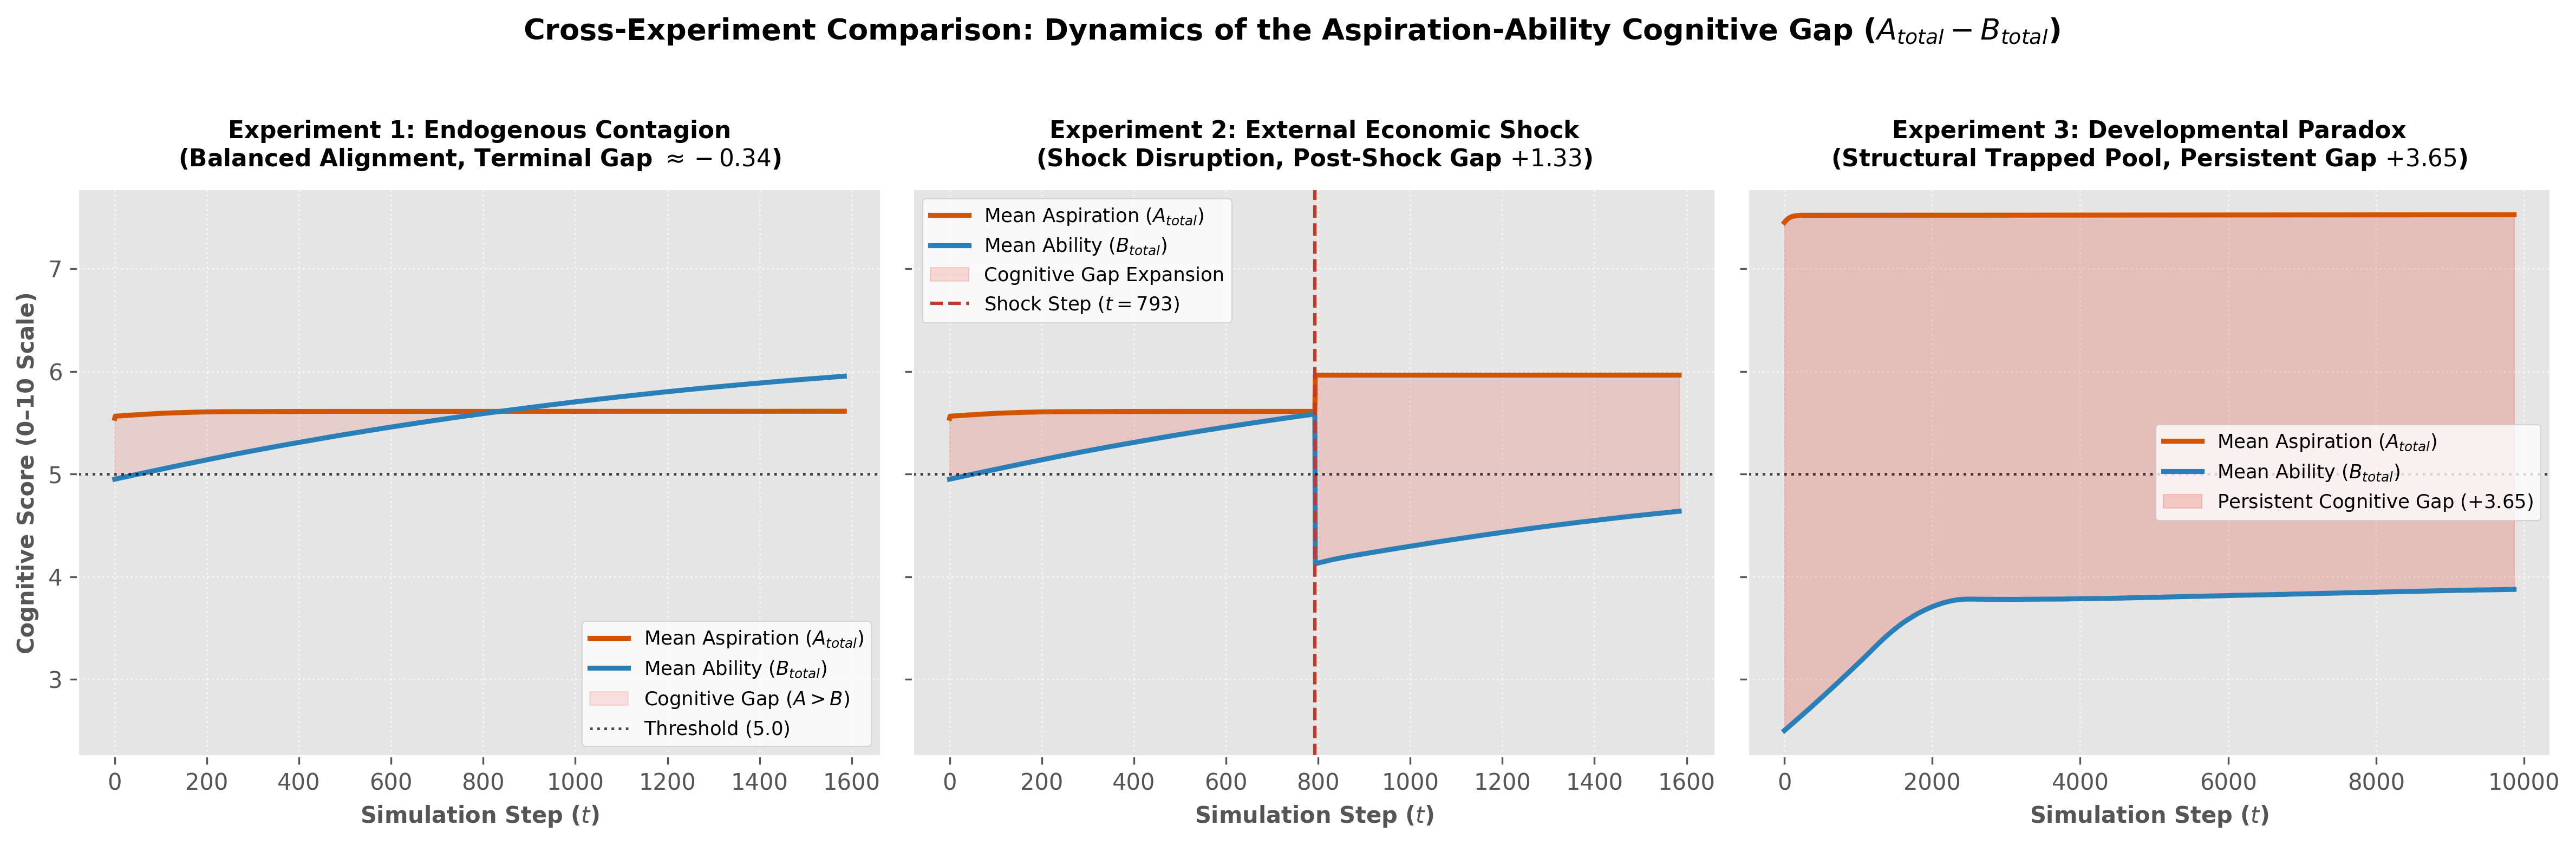

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load empirical CSVs for the 3 experiments
files = {
    'Exp1': 'Migration_CognitiveGap Experiment 1-spreadsheet.csv',
    'Exp2': 'Migration_CognitiveGap Experiment 2-spreadsheet.csv',
    'Exp3': 'Migration_CognitiveGap Experiment 3-spreadsheet.csv'
}

data_dict = {}

for name, filepath in files.items():
    with open(filepath, 'r') as f:
        lines = f.readlines()

    run_line_idx = next(i for i, line in enumerate(lines) if line.startswith('"[run number]"'))
    data_start_idx = next(i for i, line in enumerate(lines) if line.startswith('"[all run data]"'))

    run_numbers = [x.strip().replace('"', '') for x in lines[run_line_idx].split(',')]
    data_headers = [x.strip().replace('"', '') for x in lines[data_start_idx].split(',')]

    df_data = pd.read_csv(filepath, skiprows=data_start_idx + 1, header=None)

    runs_data = {}
    steps_series = None

    for col_idx in range(len(run_numbers)):
        r_num = run_numbers[col_idx]
        r_hdr = data_headers[col_idx]

        if r_num.isdigit():
            r_id = int(r_num)
            if r_id not in runs_data:
                runs_data[r_id] = {}

            series = df_data.iloc[:, col_idx].astype(float)
            runs_data[r_id][r_hdr] = series

            if r_hdr == '[step]' and steps_series is None:
                steps_series = series

    # Mean across runs
    asp_df = pd.DataFrame({f'Run_{r_id}': runs_data[r_id]['mean-aspiration-level'] for r_id in runs_data}).mean(axis=1)
    abil_df = pd.DataFrame({f'Run_{r_id}': runs_data[r_id]['mean-ability-level'] for r_id in runs_data}).mean(axis=1)
    gap_df = pd.DataFrame({f'Run_{r_id}': runs_data[r_id]['mean-aspiration-ability-gap'] for r_id in runs_data}).mean(axis=1)

    data_dict[name] = {
        'step': steps_series,
        'asp': asp_df,
        'abil': abil_df,
        'gap': gap_df
    }

# Create a 3-panel publication figure comparing Cognitive Gap Dynamics across the 3 Experiments
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=300, sharey=True)

# Panel 1: Experiment 1 (Baseline Social Contagion)
axes[0].plot(data_dict['Exp1']['step'], data_dict['Exp1']['asp'], color='#d35400', linewidth=2.2, label='Mean Aspiration ($A_{total}$)')
axes[0].plot(data_dict['Exp1']['step'], data_dict['Exp1']['abil'], color='#2980b9', linewidth=2.2, label='Mean Ability ($B_{total}$)')
axes[0].fill_between(data_dict['Exp1']['step'], data_dict['Exp1']['abil'], data_dict['Exp1']['asp'],
                     where=(data_dict['Exp1']['asp'] >= data_dict['Exp1']['abil']), color='#e74c3c', alpha=0.15, label='Cognitive Gap ($A > B$)')
axes[0].axhline(5.0, color='black', linestyle=':', linewidth=1.2, alpha=0.7, label='Threshold ($5.0$)')
axes[0].set_title('Experiment 1: Endogenous Contagion\n(Balanced Alignment, Terminal Gap $\\approx -0.34$)', fontsize=10.5, fontweight='bold', pad=10)
axes[0].set_xlabel('Simulation Step ($t$)', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Cognitive Score (0–10 Scale)', fontsize=10, fontweight='bold')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=8.5)

# Panel 2: Experiment 2 (External Economic Shock)
axes[1].plot(data_dict['Exp2']['step'], data_dict['Exp2']['asp'], color='#d35400', linewidth=2.2, label='Mean Aspiration ($A_{total}$)')
axes[1].plot(data_dict['Exp2']['step'], data_dict['Exp2']['abil'], color='#2980b9', linewidth=2.2, label='Mean Ability ($B_{total}$)')
axes[1].fill_between(data_dict['Exp2']['step'], data_dict['Exp2']['abil'], data_dict['Exp2']['asp'],
                     where=(data_dict['Exp2']['asp'] >= data_dict['Exp2']['abil']), color='#e74c3c', alpha=0.2, label='Cognitive Gap Expansion')
axes[1].axvline(793, color='#c0392b', linestyle='--', linewidth=1.5, label='Shock Step ($t=793$)')
axes[1].axhline(5.0, color='black', linestyle=':', linewidth=1.2, alpha=0.7)
axes[1].set_title('Experiment 2: External Economic Shock\n(Shock Disruption, Post-Shock Gap $+1.33$)', fontsize=10.5, fontweight='bold', pad=10)
axes[1].set_xlabel('Simulation Step ($t$)', fontsize=10, fontweight='bold')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=8.5)

# Panel 3: Experiment 3 (Developmental Paradox)
axes[2].plot(data_dict['Exp3']['step'], data_dict['Exp3']['asp'], color='#d35400', linewidth=2.2, label='Mean Aspiration ($A_{total}$)')
axes[2].plot(data_dict['Exp3']['step'], data_dict['Exp3']['abil'], color='#2980b9', linewidth=2.2, label='Mean Ability ($B_{total}$)')
axes[2].fill_between(data_dict['Exp3']['step'], data_dict['Exp3']['abil'], data_dict['Exp3']['asp'],
                     color='#e74c3c', alpha=0.25, label='Persistent Cognitive Gap ($+3.65$)')
axes[2].axhline(5.0, color='black', linestyle=':', linewidth=1.2, alpha=0.7)
axes[2].set_title('Experiment 3: Developmental Paradox\n(Structural Trapped Pool, Persistent Gap $+3.65$)', fontsize=10.5, fontweight='bold', pad=10)
axes[2].set_xlabel('Simulation Step ($t$)', fontsize=10, fontweight='bold')
axes[2].grid(True, linestyle=':', alpha=0.6)
axes[2].legend(loc='center right', frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=8.5)

plt.suptitle('Cross-Experiment Comparison: Dynamics of the Aspiration-Ability Cognitive Gap ($A_{total} - B_{total}$)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('cross_experiment_cognitive_gap_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

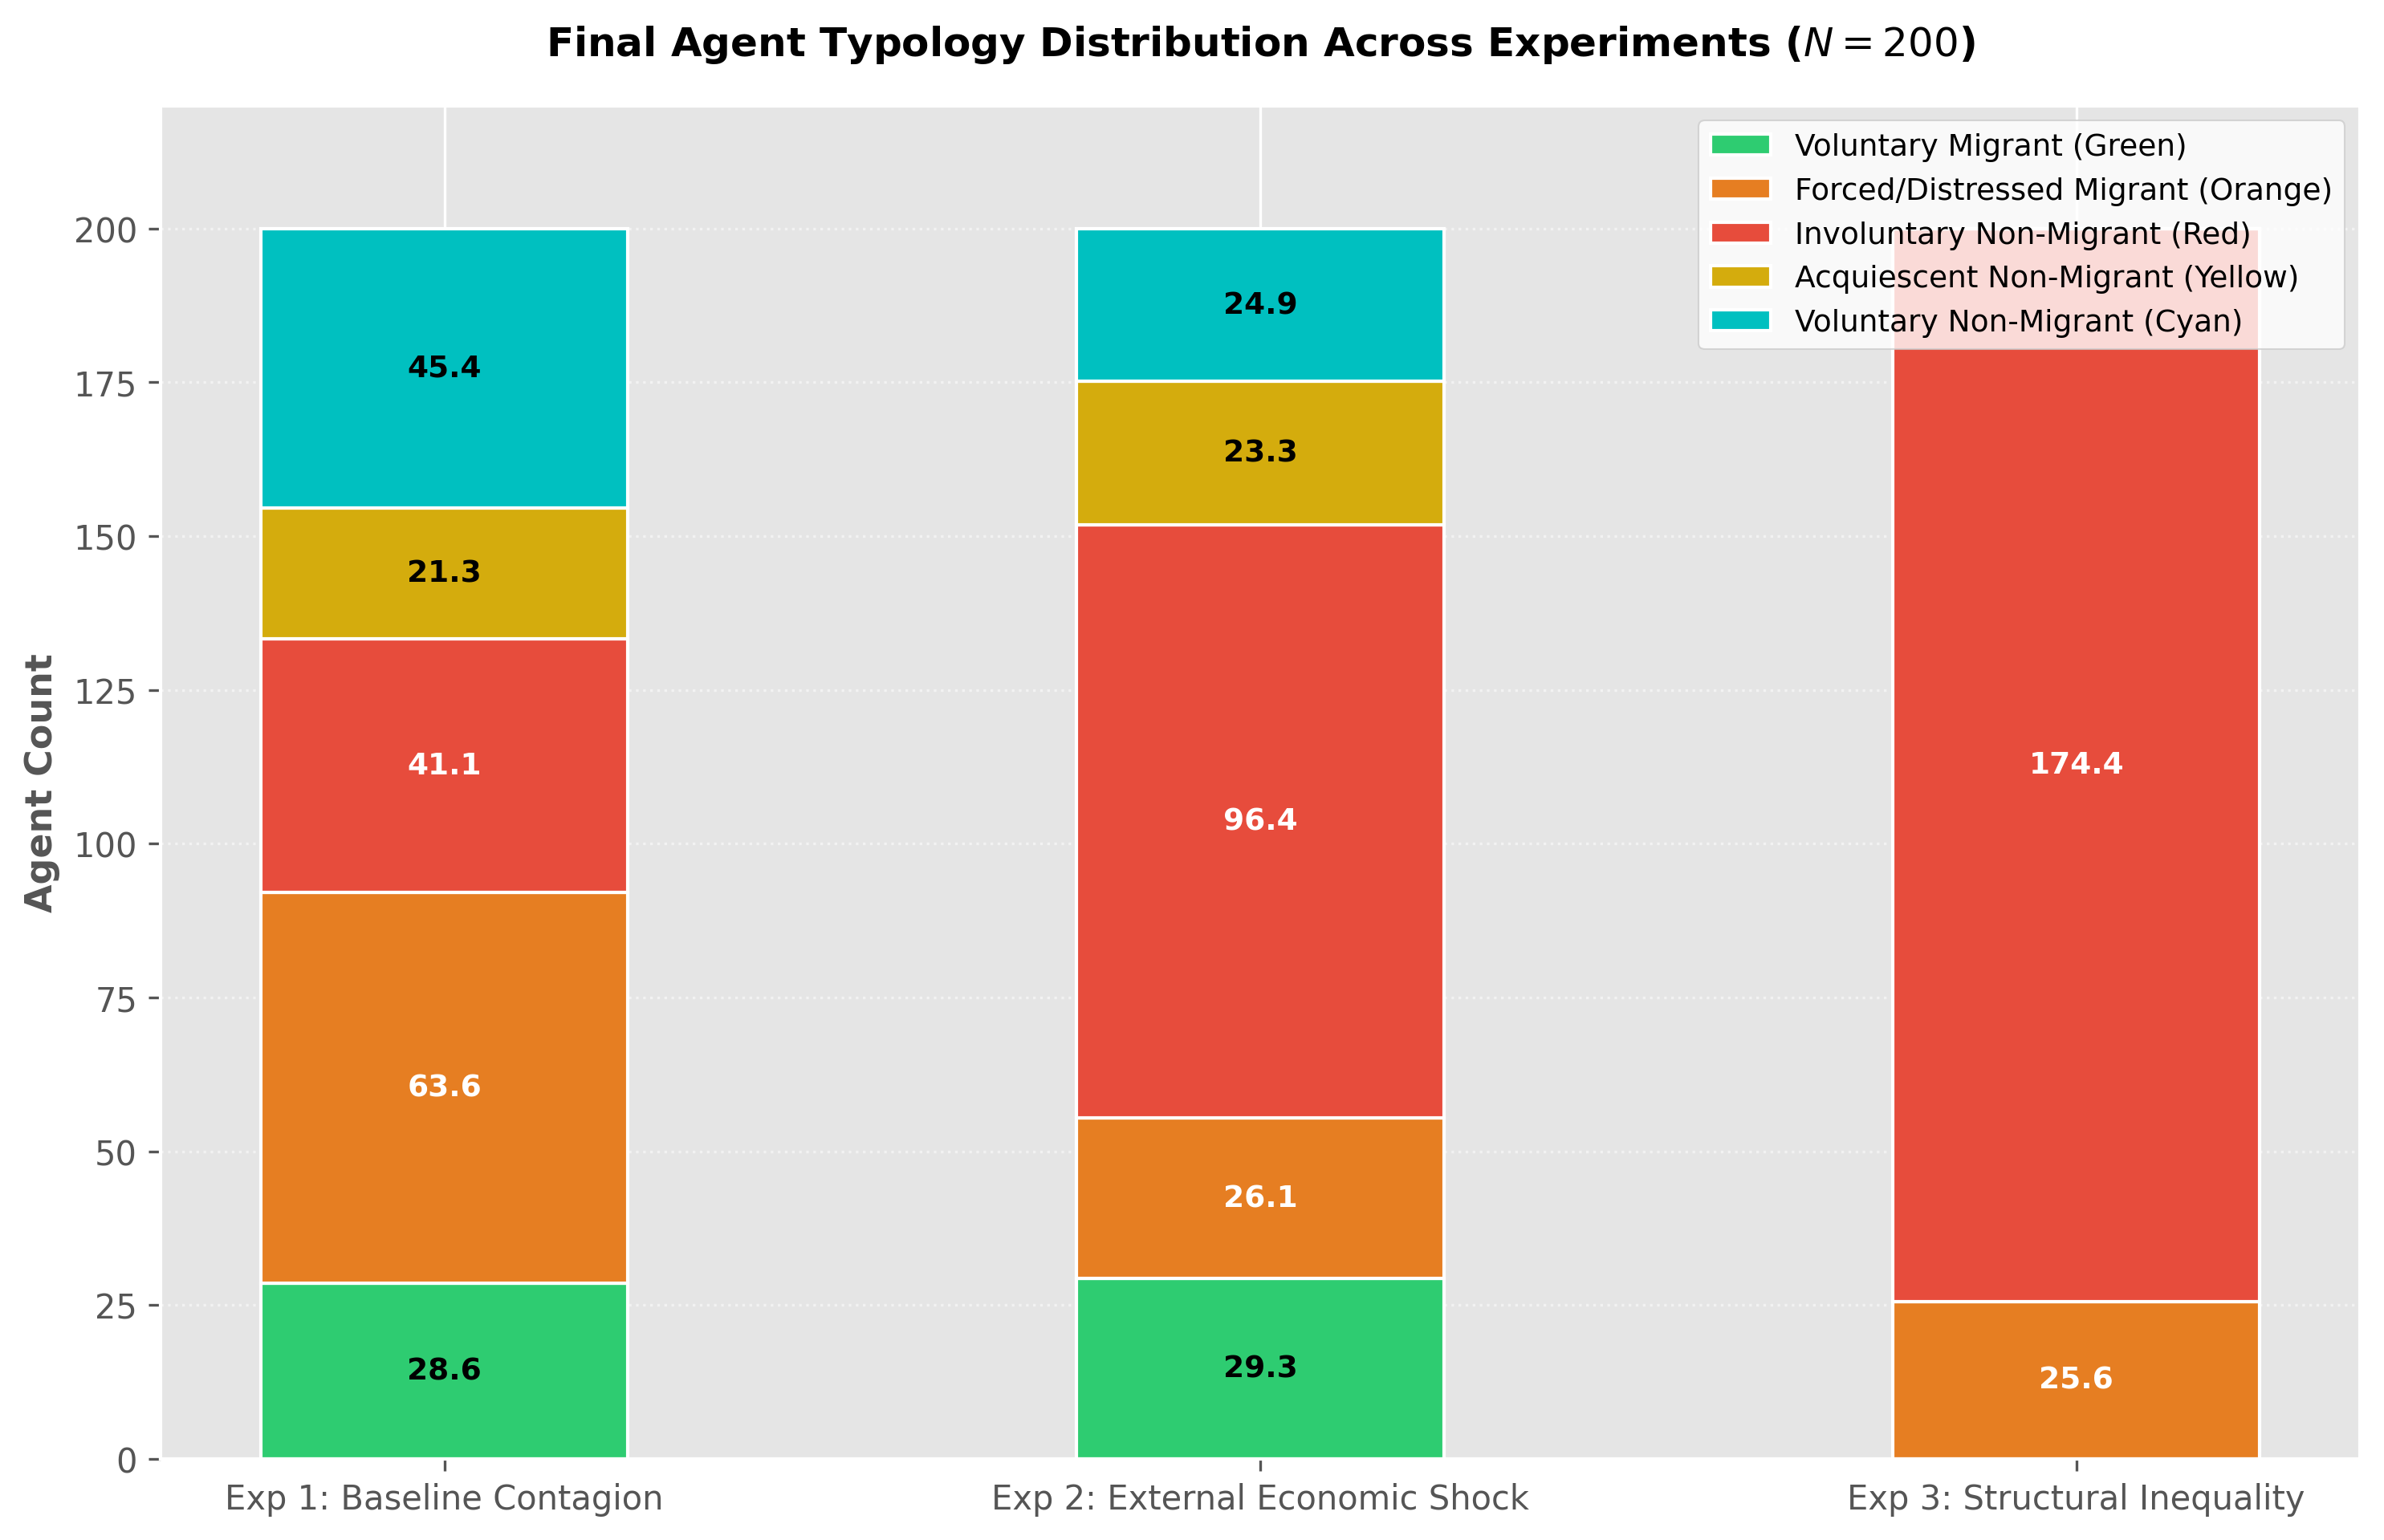

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Terminal agent typologies across all 3 experiments (7-run averages, N = 200)
typology_data = {
    'Experiment': ['Exp 1: Baseline Contagion', 'Exp 2: External Economic Shock', 'Exp 3: Structural Inequality'],
    'Voluntary Migrant (Green)': [28.57, 29.29, 0.00],
    'Forced/Distressed Migrant (Orange)': [63.57, 26.14, 25.57],
    'Involuntary Non-Migrant (Red)': [41.14, 96.43, 174.43],
    'Acquiescent Non-Migrant (Yellow)': [21.29, 23.29, 0.00],
    'Voluntary Non-Migrant (Cyan)': [45.43, 24.86, 0.00]
}

df_typology = pd.DataFrame(typology_data)

# Colors matching model typology
colors = ['#2ecc71', '#e67e22', '#e74c3c', '#d4ac0d', '#00c0c0']
categories = [
    'Voluntary Migrant (Green)',
    'Forced/Distressed Migrant (Orange)',
    'Involuntary Non-Migrant (Red)',
    'Acquiescent Non-Migrant (Yellow)',
    'Voluntary Non-Migrant (Cyan)'
]

fig, ax = plt.subplots(figsize=(10, 6.5), dpi=300)

bottoms = np.zeros(len(df_typology))

for cat, col in zip(categories, colors):
    values = df_typology[cat].values
    bars = ax.bar(df_typology['Experiment'], values, bottom=bottoms, color=col, label=cat, width=0.45, edgecolor='white', linewidth=1.0)

    # Add count labels inside segments
    for i, (val, b_val) in enumerate(zip(values, bottoms)):
        if val > 10.0:
            ax.text(i, b_val + val / 2.0, f'{val:.1f}', ha='center', va='center',
                    color='black' if col in ['#2ecc71', '#d4ac0d', '#00c0c0'] else 'white',
                    fontsize=9, fontweight='bold')

    bottoms += values

ax.set_title('Final Agent Typology Distribution Across Experiments ($N = 200$)', fontsize=12, fontweight='bold', pad=15)
ax.set_ylabel('Agent Count', fontsize=11, fontweight='bold')
ax.set_ylim(0, 220)
ax.grid(True, linestyle=':', alpha=0.5, axis='y')
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#cccccc', fontsize=9)

plt.tight_layout()
plt.savefig('terminal_agent_typologies_comparison.png', dpi=300, bbox_inches='tight')
plt.show()